# Physical climate risk in a Brazilian credit book

This synthetic exercise frames a Brazilian bank's physical-risk reporting to Banco Central do Brasil from the 31 December 2027 reference date under Resolução BCB nº 586/2026. It follows six Brazilian borrowers, twelve loans and ten financed sites from climate-risk reporting to site hazards, selected monetary impacts and flood-related credit effects. The book and calculations are illustrative; they are not a filing or a validated bank risk model.

The key question is how much the reported picture changes when exposures are located at financed sites rather than borrower headquarters, and what that means for physical and credit risk.


<a id="index" name="index"></a>

### Contents

1. [Setup and inputs](#s1)
2. [The bank's book](#s2)
3. [CRFR2: where exposure is reported](#s3)
4. [Hazards at financed sites](#s4)
5. [Which impacts become money](#s5)
6. [Portfolio aggregation](#s6)
7. [Flood and loans](#s7)
8. [Results and exported tables](#s8)


<a id="s1" name="s1"></a>

## 1. Setup and inputs

Use the repository README to set up the environment and API credentials. Edit the run settings in Section 1.2 and the illustrative assumptions in Section 1.4; edit the borrower, loan and site registers under `resources/brazil/` to change the example book.

Each section requests its data in the cell before its first result. After changing a setting, re-run the notebook from Section 1.2.


In [1]:
import json
import os
import sys
import time
from pathlib import Path

NOTEBOOKS_ROOT = Path.cwd().parent
for path in (NOTEBOOKS_ROOT, Path.cwd()):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import numpy as np
import pandas as pd
import plotly.io as pio
from plotly.offline import init_notebook_mode
import requests
from dotenv import load_dotenv
from IPython.display import display

import auxiliary_brazil as br
import brazil_figures as bf
from auxiliary_functions import financial_metrics_plots as fmp
from auxiliary_functions import geometry_maps_plots as gmp
from auxiliary_functions import tail_metrics as tm
from auxiliary_functions.pipeline_client import PhysicalAssetPipeline

init_notebook_mode(connected=False)
pio.templates.default = "brazil"
pd.set_option("display.width", 160)


<a id="s1-1" name="s1-1"></a>

### 1.1 Data access

The notebook uses Alpha-Klima for site-level hazard and impact data and AdaptaBrasil for municipal indices and CRFR2 grids.

Add `ALPHA_KLIMA_API_KEY` and `ALPHA_KLIMA_API_BASE_URL` to the repository `.env` file; the README explains how to obtain credentials.


In [2]:
load_dotenv("../../.env")
API_KEY = os.environ.get("ALPHA_KLIMA_API_KEY")
API_BASE = os.environ.get("ALPHA_KLIMA_API_BASE_URL", "").rstrip("/")
HEADERS = {"X-API-Key": API_KEY, "Accept": "application/json"}
assert API_KEY and API_BASE, "Set ALPHA_KLIMA_API_KEY and ALPHA_KLIMA_API_BASE_URL in ../../.env (section 1.1)"

def api_post(path, payload, retries=4, timeout=300):
    for attempt in range(retries):
        response = requests.post(API_BASE + path, json=payload, headers=HEADERS, timeout=timeout)
        if response.status_code < 500 or attempt + 1 == retries:
            response.raise_for_status()
            return response.json()
        time.sleep(3 * (attempt + 1))

def api_get(path, params=None):
    response = requests.get(API_BASE + path, params=params, headers=HEADERS, timeout=300)
    response.raise_for_status()
    return response

def read_curves(requests):
    groups = {"curves": requests}
    return br.curve_frames(api_post("/api/get_hazard_data", {"items": br.curve_items(groups)}),
                           groups)["curves"]

def impacts(sites, scope, scenarios, years, hazard_paths=None):
    items = [br.asset_item(row) for _, row in sites.iterrows()]
    return br.impact_frame(api_post("/api/get_asset_impact_clean",
                                    br.impact_payload(items, scope, scenarios, years, hazard_paths)))


<a id="s1-2" name="s1-2"></a>

### 1.2 Run settings

The settings below choose the pathways, baseline years, flood event and reference date. River and coastal flood and warm river water use RCP pathways; heat and water stress use SSP pathways. The CRFR2 scenario is fixed by the regulation. The 2030 flood and warm-water baselines are the first projected year of each dataset, not an observed period.

Table 1.3.1 lists the available horizons for each dataset. After editing these settings or the assumptions in Section 1.4, re-run the notebook from here.


In [3]:
ASSETS_FILE = "../../resources/brazil/brazil_assets.json"
CLIENTS_FILE = "../../resources/brazil/brazil_clients.csv"
FACILITIES_FILE = "../../resources/brazil/brazil_facilities.csv"
MUNICIPALITIES_FILE = "../../resources/brazil/br_municipios_0.03deg.geojson"
HAZARD_MAPS_FILE = "../../resources/brazil/hazard_maps.npz"
OUTPUTS = Path("outputs")
OUTPUTS.mkdir(exist_ok=True)

COMPARE = {
    "riverine": {"baseline": 2030, "compared": [("rcp8p5", 2080)]},
    "coastal": {"baseline": 2030, "compared": [("rcp8p5", 2050), ("rcp8p5", 2080),
                                               ("rcp4p5", 2050), ("rcp4p5", 2080)]},
    "warm_water": {"baseline": 2030, "compared": [("rcp8p5", 2050), ("rcp8p5", 2080),
                                                  ("rcp4p5", 2050), ("rcp4p5", 2080)]},
    "heat": {"baseline": ("historical", 2005),
             "compared": [("ssp585", 2030), ("ssp585", 2050), ("ssp245", 2030), ("ssp245", 2050)]},
    "water_stress": {"baseline": ("historical", 1999), "compared": [("ssp585", 2030), ("ssp585", 2050)]},
}
FOCUS_SCENARIO = "rcp8p5"
FOCUS_HEAT_SCENARIO = "ssp585"
FOCUS_YEAR = 2050
FOCUS_RP = 100.0

RIVER_MODEL = "HadGEM2-ES"
COASTAL_RESOURCE = "nosub 50%"
COASTAL_RANGE = ("nosub 5%", "nosub 95%")
COASTAL_SUBSIDENCE = "wtsub 50%"

CHRONIC_HEAT = {"cdd": ("ChronicHeat", "cooling_degree_days/index", "ERA5-Land"),
                "wbgt": ("ChronicHeat", "days_wbgt_above", "ACCESS-CM2")}

WORK_LOSS_MODEL = "NorESM2-MM"
WORK_LOSS = {intensity: ("ChronicHeat", f"mean_work_loss/{intensity}", WORK_LOSS_MODEL)
             for intensity in ("low", "medium", "high")}
DEGREE_DAYS_32C = ("ChronicHeat", "mean_degree_days/above/32c", "ACCESS-CM2")
WARM_WATER = ("ChronicHeat", "weeks_water_temp_above", "HadGEM")
WARM_WATER_THRESHOLD = 30.0
WATER_STRESS = ("WaterRisk", "water_stress", "combined")

IMPACT_ROUTING = {"IndustrialActivity": "mean_degree_days/above/32c",
                  "ManufacturingAsset": "days_wbgt_above",
                  "RealEstateAsset": "cooling_degree_days/index"}

REFERENCE_YEAR = 2027
LOAN_VINTAGES = (2040, 2050, 2080)
TAIL_PERCENTILES = (95.0, 99.0, 99.5)
SENSITIVITY_RPS = (20.0, 50.0, 100.0, 200.0)
PORTFOLIO_NAME = "brazil_ten_assets"

FLOOD_FAMILIES = ("riverine", "coastal")
BASELINE_YEAR = COMPARE["riverine"]["baseline"]
FLOOD_SCENARIOS = {f: sorted({s for s, _ in COMPARE[f]["compared"]}) for f in FLOOD_FAMILIES}
FLOOD_YEARS = {f: tuple(sorted({BASELINE_YEAR, *(y for _, y in COMPARE[f]["compared"])}))
               for f in FLOOD_FAMILIES}
COMPARISON_YEARS_BY_FAMILY = {f: tuple(sorted(y for s, y in COMPARE[f]["compared"] if s == FOCUS_SCENARIO))
                              for f in FLOOD_FAMILIES}
COMPARISON_YEARS = tuple(sorted({y for years in COMPARISON_YEARS_BY_FAMILY.values() for y in years}))
HEAT_SCENARIOS = sorted({s for s, _ in COMPARE["heat"]["compared"]})
HEAT_YEARS = sorted({y for _, y in COMPARE["heat"]["compared"]})
HEAT_COMBOS = br.comparison_combos(COMPARE["heat"])
FOCUS_HEAT = f"{FOCUS_HEAT_SCENARIO} {FOCUS_YEAR}"
FLOOD_LABELS = (RIVER_MODEL, br.COASTAL_BASELINE, COASTAL_RESOURCE, *COASTAL_RANGE, COASTAL_SUBSIDENCE)

def _against(pairs):
    return "; ".join(f"{s} {' and '.join(str(y) for t, y in pairs if t == s)}"
                     for s in dict.fromkeys(s for s, _ in pairs))

FLOOD_READING = (f"River: WRI {RIVER_MODEL}, {BASELINE_YEAR} against {_against(COMPARE['riverine']['compared'])}. "
                 f"Coast: WRI {COASTAL_RESOURCE} (range {' to '.join(COASTAL_RANGE)}), {BASELINE_YEAR} "
                 f"against {_against(COMPARE['coastal']['compared'])}.")


<a id="s1-3" name="s1-3"></a>

### 1.3 Datasets

Table 1.3.1 lists the series and horizons used below; Table 1.3.2 names the closest AdaptaBrasil indicators for the map comparisons. The following cell resolves the Alpha-Klima dataset paths; the national map grids are precomputed.


**Table 1.3.1. The datasets this notebook uses.**

| Section | Series | Provider | Units | Scenario · horizon |
|---|---|---|---|---|
| 4.1 | Drought | Alpha-Klima, ERA5-Land | mean SPEI, drier shown larger | historical 2005 |
| 4.2 | Water stress | WRI Aqueduct 4.0 | withdrawals over supply | historical 1999; compared ssp585 2030, 2050 |
| 4.3, 5.3, 7 | River flood | WRI Aqueduct Floods (HadGEM2-ES) | metres of water, 2 to 1,000 years | 2030 baseline; compared rcp8p5 2080 |
| 4.3, 4.5, 5.5, 7 | Coastal flood | WRI Aqueduct Floods | metres of water, 2 to 1,000 years | 2030 baseline; compared rcp8p5 and rcp4p5, 2050 and 2080 |
| 4.5.2 | Sea-level rise | WRI Aqueduct Floods | metres of extra water | rcp8p5 and rcp4p5, 2030, 2050, 2080 |
| 4.5.3 | Land subsidence | WRI Aqueduct Floods | metres of extra water | rcp8p5 and rcp4p5, 2030, 2050, 2080 |
| 4.4, 5.4 | Cooling degree days | Alpha-Klima, ERA5-Land | °C·day per year at 18 °C | historical 2005; compared ssp585 and ssp245, 2030 and 2050 |
| 4.4, 5.4 | Days above a WBGT threshold | OS-Climate, ACCESS-CM2 | days per year | historical 2005; compared ssp585 and ssp245, 2030 and 2050 |
| 5.4 | Degree days above 32 °C | OS-Climate, ACCESS-CM2 | °C·day per year above 32 °C | historical 2005; compared ssp585 and ssp245, 2030 and 2050 |
| 4.4, 5.4 | Mean work loss, low, medium and high intensity | OS-Climate, NorESM2-MM | share of a working year lost | historical 2005; compared ssp585 and ssp245, 2030 and 2050 |
| 4.4.4 | Weeks of warm water (HadGEM2-ES) | Utrecht University | weeks per year above 30 °C | 2030 baseline; compared rcp8p5 and rcp4p5, 2050 and 2080 |

**Table 1.3.2. Alpha-Klima datasets and their AdaptaBrasil counterparts.** The table identifies the closest AdaptaBrasil indicator, where available, for each series used in the notebook.

| Series | Alpha-Klima provider | AdaptaBrasil counterpart |
|---|---|---|
| Drought | Alpha-Klima, ERA5-Land | SPEI (5047), present 2017 |
| Water stress, national map | WRI Aqueduct 4.0 | Nível de comprometimento do balanço hídrico pelas atividades produtivas (9), 2020 |
| Flood, national map (the deeper of river and coast) | WRI Aqueduct Floods | Índice de ameaça de inundações, enxurradas e alagamentos (60044), RCP8.5 2050 |
| Cooling degree days | Alpha-Klima, ERA5-Land | Número de ondas de calor (50103), RCP8.5 2050 |

In [4]:
INVENTORY = api_post("/api/get_hazard_data_availability", {"types": [], "sources": ["strings"]})["models"]

def dataset_path(hazard_type, indicator_id, model):
    return next(entry["path"] for entry in INVENTORY
                if (entry["hazard_type"], entry["indicator_id"], entry["indicator_model_gcm"])
                == (hazard_type, indicator_id, model))

WATER_STRESS_PATH = dataset_path(*WATER_STRESS)

COASTAL, RIVER = br.wri_flood_resources(INVENTORY)
FLOOD_LAYERS = [(family, resource) for family, resources in (("coastal", COASTAL), ("riverine", RIVER))
                for resource in resources if resource["label"] in FLOOD_LABELS]
assert {resource["label"] for _, resource in FLOOD_LAYERS} == set(FLOOD_LABELS), "a flood layer is not published"
FLOOD_PATHS = {resource["label"]: resource["path"]
               for family in FLOOD_FAMILIES for f, resource in FLOOD_LAYERS if f == family}

HEAT_PATHS = {indicator: dataset_path(hazard_type, indicator, model) for hazard_type, indicator, model in
              (*CHRONIC_HEAT.values(), DEGREE_DAYS_32C, *WORK_LOSS.values())}

WARM_WATER_PATH = dataset_path(*WARM_WATER)

print(f"{len(INVENTORY)} datasets in the inventory. Read here:")
for series, path in {"water stress": WATER_STRESS_PATH,
                     **{f"flood, {label}": path for label, path in FLOOD_PATHS.items()},
                     **HEAT_PATHS, "warm water": WARM_WATER_PATH}.items():
    print(f"  {series}: {path}")


128 datasets in the inventory. Read here:
  water stress: water_risk/wri/v2/water_stress_{scenario}_{year}
  flood, HadGEM2-ES: inundation/wri/v2/inunriver_{scenario}_0000HadGEM2-ES_{year}
  flood, baseline nosub: inundation/wri/v2/inuncoast_historical_nosub_hist_0
  flood, nosub 95%: inundation/wri/v2/inuncoast_{scenario}_nosub_{year}_0
  flood, nosub 5%: inundation/wri/v2/inuncoast_{scenario}_nosub_{year}_0_perc_05
  flood, nosub 50%: inundation/wri/v2/inuncoast_{scenario}_nosub_{year}_0_perc_50
  flood, wtsub 50%: inundation/wri/v2/inuncoast_{scenario}_wtsub_{year}_0_perc_50
  cooling_degree_days/index: chronic_heat/alpha_klima/v1/cooling_degree_days_index_{scenario}_{year}
  days_wbgt_above: chronic_heat/osc/v2/days_wbgt_above_ACCESS-CM2_{scenario}_{year}
  mean_degree_days/above/32c: chronic_heat/osc/v2/mean_degree_days_v2_above_32c_ACCESS-CM2_{scenario}_{year}
  mean_work_loss/low: chronic_heat/osc/v2/mean_work_loss_low_NorESM2-MM_{scenario}_{year}
  mean_work_loss/medium: chroni

<a id="s1-4" name="s1-4"></a>

### 1.4 Values to replace

These values stand in for site or borrower information a bank would verify: electricity use and price, and labour cost. The comment above each value gives its unit and the source that should replace it.

The book's files also hold placeholders:
- per site, in `resources/brazil/brazil_assets.json`: the ground above the flood cell and the floor area, which a real book would take from a site survey;
- per producing site, in the same file: the share of its revenue earned by heavy, moderate and light work exposed to heat (section 5.4.1), which a real book would take from the borrower's workforce by task;
- per loan, in `resources/brazil/brazil_facilities.csv`: the split of each borrower's EAD and each loan's tenor (Table 2.2.1), which a real book would take from its loan system.


In [5]:
COOLING_KWH_PER_M2_YEAR = 80.0

ELECTRICITY_PRICE_BRL_PER_KWH = 0.85

LABOUR_SHARE = 0.12

COOLING = {"kwh_per_m2_year": COOLING_KWH_PER_M2_YEAR, "price_per_kwh": ELECTRICITY_PRICE_BRL_PER_KWH}


<a id="s1-5" name="s1-5"></a>

### 1.5 The book's inputs

The example contains six borrowers, twelve loans and ten financed sites. The borrower and site registers determine the reporting location in Section 3 and the hazard exposure in Section 4. Replace these synthetic records with verified bank and site data for a real portfolio.


In [6]:
assets = pd.DataFrame(json.loads(Path(ASSETS_FILE).read_text(encoding="utf-8"))["items"])
assets["geocod_ibge"] = assets["geocod_ibge"].astype(str)

clients = pd.read_csv(CLIENTS_FILE)
clients["hq_geocod_ibge"] = clients["hq_geocod_ibge"].astype(str)

assert assets["id"].is_unique, "asset ids must be unique"
assert assets["geocod_ibge"].is_unique, "one asset per municipality, or the join double-counts"
assert clients["client_id"].is_unique, "client ids must be unique"
assert set(assets["client_id"]) == set(clients["client_id"]), "every asset needs a known client"

facilities = pd.read_csv(FACILITIES_FILE)
assert set(facilities["client_id"]) == set(clients["client_id"]), "every client needs its loans"
assert (facilities.groupby("client_id")["share_of_ead"].sum() - 1).abs().max() < 1e-9, (
    "each client's loan shares must add up to one")
facilities["ead"] = (facilities["client_id"].map(clients.set_index("client_id")["ead_basel_brl"])
                     * facilities["share_of_ead"])

ASSET_IDS = list(assets["id"])
COLOUR = bf.colour_by_id(ASSET_IDS)

print(f"{len(clients)} clients | {len(facilities)} loans | {len(assets)} assets | "
      f"{br.CURRENCY} {assets['value'].sum() / 1e6:,.0f} M collateral | "
      f"{br.CURRENCY} {clients['drawn_brl'].sum() / 1e6:,.0f} M drawn | {API_BASE}")


6 clients | 12 loans | 10 assets | R$ 1,618 M collateral | R$ 971 M drawn | https://test.alpha-klima.com/prapi


<a id="s1-6" name="s1-6"></a>

### 1.6 Figure colours

The palette below keeps each site's colour consistent across figures. Change a colour here and re-run the figure cells to update it. Site colours are assigned with the book inputs in Section 1.5; CRFR2 risk-level colours follow the regulation.


<a id="s2" name="s2"></a>

## 2. The bank's book

The book links each borrower and loan to the sites it finances. Headquarters can be far from those sites, so the regulatory filing location may not represent where the physical exposure sits. Section 3 compares the same exposures at both locations.


<a id="s2-clients" name="s2-clients"></a>

### 2.1 Clients

Table 2.1.1 summarizes the borrowers, their headquarters, credit inputs and exposure. Borrower type and sector determine the CRFR2 rows; PD, LGD, EAD and maturity feed the illustrative credit calculation in Section 7.


In [7]:
book = br.book_table(clients, assets)
b = book.set_index("client_id")
M = f"({br.CURRENCY} M)"
display(bf.table(pd.DataFrame({
    "Borrower": b["client_name"],
    "Counterparty type": b["counterparty_type"],
    "Headquarters": b["hq_municipality"] + "/" + b["hq_uf"],
    "Financed sites": b["assets"],
    "Sector (CRFR2 Seca)": b["crfr2_seca_sector"],
    "Rating": b["rating"],
    "PD (%)": b["pd_baseline"] * 100,
    "LGD (%)": b["lgd_baseline"] * 100,
    "Maturity (years)": b["maturity_years"],
    f"Drawn {M}": b["drawn_brl"] / 1e6,
    f"Undrawn line {M}": b["offbalance_brl"] / 1e6,
    f"EAD {M}": b["ead_basel_brl"] / 1e6,
    f"Collateral {M}": b["collateral"] / 1e6,
    f"Annual revenue {M}": b["annual_revenue_brl"] / 1e6,
    f"Problem assets {M}": b["npl_brl"] / 1e6,
    f"Expected loss {M}": b["EL_baseline"] / 1e6,
}).round(2), "Table 2.1.1. The credit book, one row per counterparty (amounts in R$ M)"))

print(f"{br.CURRENCY} {book['drawn_brl'].sum() / 1e6:,.1f} M drawn against "
      f"{br.CURRENCY} {book['collateral'].sum() / 1e6:,.1f} M of collateral | "
      f"baseline expected loss {br.CURRENCY} {book['EL_baseline'].sum() / 1e6:,.2f} M")


,Borrower,Counterparty type,Headquarters,Financed sites,Sector (CRFR2 Seca),Rating,PD (%),LGD (%),Maturity (years),Drawn (R$ M),Undrawn line (R$ M),EAD (R$ M),Collateral (R$ M),Annual revenue (R$ M),Problem assets (R$ M),Expected loss (R$ M)
client_id,,,,,,,,,,,,,,,,
C01,Grupo Oeste Agroindustrial S.A.,Pessoa Jurídica,Salvador/BA,BA3,Agricultura,BB,1.85,26.11,4.8,193.5,38.7,208.98,322.5,"1,150",0,1.01
C02,Cerrado Grãos Trading S.A.,Pessoa Jurídica,São Paulo/SP,"MT1, MT5",Agricultura,BB+,1.03,26.21,3.8,238.2,52.4,259.16,397,"4,800",0,0.7
C03,Rio São Francisco Alimentos Ltda.,Pessoa Jurídica,Belo Horizonte/MG,"AL1, MG1",Indústria de produtos alimentícios,BB-,3.32,26.11,5,145.2,29,156.8,242,820,0,1.36
C04,Cacau Litoral Sul Industria Ltda.,Pessoa Jurídica,Ilhéus/BA,"BA5, BA6",Indústria de produtos alimentícios,B+,5.98,25.85,4.6,148.8,22.3,157.72,248,610,0,2.44
C05,Usina Potiguar Bioenergia S.A.,Pessoa Jurídica,Natal/RN,"RN1, RN2",Indústria de produtos derivados de petróleo e biocombustíveis,BB-,3.32,24.67,5,167.4,33.5,180.8,279,690,0,1.48
C06,Antônio N. Lima (produtor rural),Pessoa Natural,Barreiras/BA,BA4,Agricultura,unrated,8.8,25.85,2,78,11.7,82.68,130,185,0,1.88


R$ 971.1 M drawn against R$ 1,618.5 M of collateral | baseline expected loss R$ 8.87 M


<a id="s2-parameters" name="s2-parameters"></a>

### 2.2 Credit parameters

The example assigns each borrower a probability of default (PD), loss given default (LGD), exposure at default (EAD) and maturity. These are illustrative inputs, not estimates calibrated for a bank. EAD adds 40% of each undrawn line to the drawn balance.

Table 2.2.1 divides each borrower's EAD between a seasonal line and a term loan. The tenors matter when Section 7 compares today's loans with loans written later.


In [8]:
f = facilities.set_index(["client_id", "facility_id"]).rename_axis(["Borrower", "Loan"])
runs = [br.loan_years(tenor, REFERENCE_YEAR + 1) for tenor in f["tenor_years"]]
display(bf.table(pd.DataFrame({
    "Kind": f["facility_type"],
    "Finances": f["purpose"],
    "Share of the borrower's EAD (%)": (f["share_of_ead"] * 100).round(),
    f"EAD ({br.CURRENCY} M)": (f["ead"] / 1e6).round(1),
    "Tenor (years)": f["tenor_years"],
    "Today's loan runs": [str(r[0]) if len(r) == 1 else f"{r[0]}–{r[-1]}" for r in runs],
    "At maturity": f["at_maturity"],
}), "Table 2.2.1. The loans behind each borrower: what each finances, its share of the "
    "borrower's EAD, its tenor, and what the bank does at maturity"))


<a id="s2-assets" name="s2-assets"></a>

### 2.3 Financed assets

Table 2.3.1 lists the ten sites, their locations, asset classes and values. Coordinates locate the hazards in Section 4; the ground above the flood cell sets the water on each site in Section 4.3.3. All site values are illustrative, not appraisals.

Figure 2.3.1 shows the borrower headquarters and the financed sites. A headquarters-based filing can place exposure in a different municipality or region from the activity it finances.


In [9]:
a = assets.set_index("id").rename_axis("Site")
display(bf.table(pd.DataFrame({
    "Borrower": a["client_id"],
    "Name": a["name"],
    "Municipality": a["municipality"],
    "UF": a["uf"],
    "Asset class": a["asset_class"],
    "Latitude": a["latitude"],
    "Longitude": a["longitude"],
    "Ground above the flood cell (m)": a["site_elevation_above_cell_m"],
    "Hazards flagged": a["hazards"].map(", ".join),
    f"Value ({br.CURRENCY} M)": (a["value"] / 1e6).round(1),
    f"Annual revenue ({br.CURRENCY} M)": (a["annual_revenue"] / 1e6).round(1),
    "Annual output": a["annual_output"].map("{:,.0f}".format) + " " + a["output_unit"],
}), "Table 2.3.1. The asset register: location, asset class, ground above the flood cell "
    "(m), the climate hazards each site carries and its value (R$ M)"))


,Borrower,Name,Municipality,UF,Asset class,Latitude,Longitude,Ground above the flood cell (m),Hazards flagged,Value (R$ M),Annual revenue (R$ M),Annual output
Site,,,,,,,,,,,,
AL1,C03,Armazém de Piaçabuçu,Piaçabuçu,AL,IndustrialActivity,-10.4016,-36.4547,1.5,"coastal, riverine, heat, water, drought",87,115,"60,000 t of rice dried and sold"
BA6,C04,Terminal Portuário de Nova Viçosa,Nova Viçosa,BA,IndustrialActivity,-17.87,-39.355,0.5,"coastal, heat",136.5,70,"450,000 t handled"
MG1,C03,Terminal Fluvial de Pirapora,Pirapora,MG,IndustrialActivity,-17.2914,-44.9266,4,"riverine, heat, drought",155,60,"1,200,000 t of grain transhipped"
BA5,C04,Unidade de Beneficiamento de Itagibá,Itagibá,BA,ManufacturingAsset,-14.137,-39.737,7,"riverine, heat",111.5,320,"12,000 t of cocoa beans processed"
BA3,C01,Usina de Beneficiamento São Desidério,São Desidério,BA,ManufacturingAsset,-12.36,-44.97,1,"riverine, heat, water",322.5,540,"60,000 t of cotton lint"
BA4,C06,Unidade de Armazenagem Formosa do Rio Preto,Formosa do Rio Preto,BA,IndustrialActivity,-11.05,-45.19,2,"riverine, heat, drought",130,150,"75,000 t of soybeans stored and sold"
MT5,C02,Centro de Distribuição Cuiabá,Cuiabá,MT,IndustrialActivity,-15.62,-56.05,2,"heat, drought",118,48,"600,000 t of grain handled"
MT1,C02,Terminal Graneleiro Rondonópolis,Rondonópolis,MT,IndustrialActivity,-16.44,-54.58,3,"heat, drought",279,140,"2,000,000 t of grain loaded to rail"
RN1,C05,Usina Sucroalcooleira do Ceará-Mirim,Taipu,RN,ManufacturingAsset,-5.62,-35.52,0.3,"riverine, heat, water, drought",192,300,"1,500,000 t of sugarcane crushed"


In [10]:
exposures = br.build_exposures(assets, clients)

assert abs(exposures["gross_brl"].sum() - clients["drawn_brl"].sum()) < 1.0, "drawn balance must reconcile"
print(f"{len(exposures)} exposure rows | {br.CURRENCY} {exposures['gross_brl'].sum() / 1e6:,.1f} M "
      f"gross | {br.CURRENCY} {exposures['offbal_brl'].sum() / 1e6:,.1f} M off-balance")


10 exposure rows | R$ 971.1 M gross | R$ 187.6 M off-balance


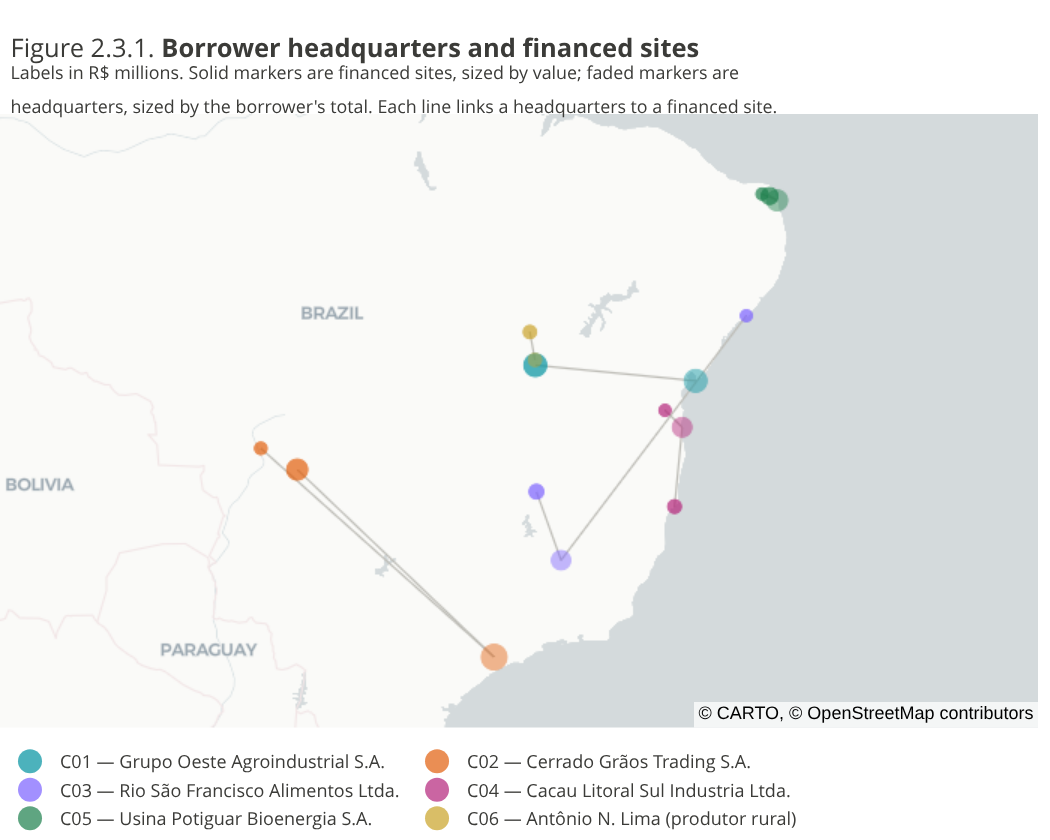

In [11]:
figure = bf.hq_asset_map(exposures)
bf.set_text(
    figure,
    title="Borrower headquarters and financed sites",
    subtitle=(f"Labels in {br.CURRENCY} millions. Solid markers are financed sites, sized by value; "
              "faded markers are headquarters, sized by the borrower's total. Each line links a "
              "headquarters to a financed site."))
bf.finalise(figure, "Figure 2.3.1")


**What the map shows.** Every borrower's sites lie in a different municipality from its headquarters, and for C02 and C03 in a different macro-region. Section 3 files the same reporting tables twice, once at the headquarters and once at each site's location, to measure how that difference changes what the bank reports.


<a id="s3" name="s3"></a>

## 3. CRFR2: where exposure is reported

CRFR2 is the table of the GRSAC report, required by Resolução BCB nº 586/2026 (layouts in IN BCB nº 772), in which a bank reports its exposure to physical climate hazards by macro-region. It has two grids: *Seca*, with one row per economic sector, and *Chuva Intensa*, with one row per counterparty type.

For each of the five regions, a row carries the gross and problematic exposure and a risk level for the present and 2030: the exposure-weighted mean of AdaptaBrasil's municipal threat index, in five classes from *Muito baixo* to *Muito alto*.

The same exposures are filed once at borrower headquarters (*Nível 3*) and once at the financed-site municipality (*Nível 1*), so the comparison isolates the effect of the reporting location. The indices are municipal threat indices, not site-level hazard readings or composite physical-risk scores.


**Figure 3.1.** Only the rows filled in each CRFR2 grid are shown. Each bar is one grid row: the gross exposure of the counterparties assigned to it, summed over the five regions, with the undrawn line beside it. No exposure in the example book is problematic, so the figure draws no problematic part; the CRFR2 grids keep their *Ativos problemáticos* column, at zero, because the layout lists it.


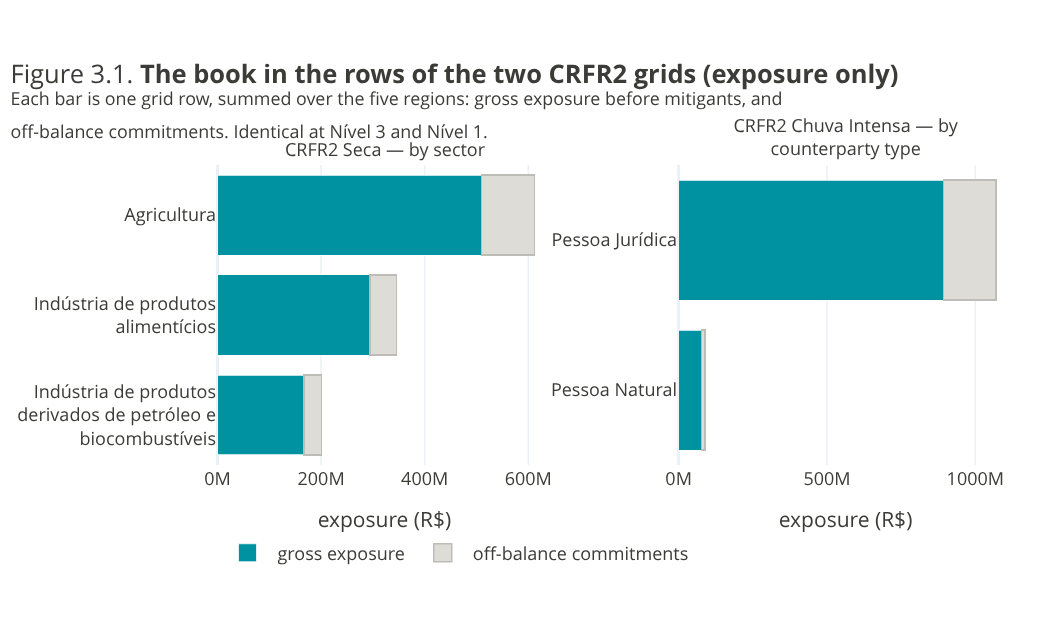

In [12]:
figure = bf.book_by_table_figure(exposures)
bf.set_text(
    figure,
    title="The book in the rows of the two CRFR2 grids (exposure only)",
    subtitle=("Each bar is one grid row, summed over the five regions: gross exposure before "
              "mitigants, and off-balance commitments. Identical at Nível 3 and Nível 1."),
    panels=("CRFR2 Seca — by sector", "CRFR2 Chuva Intensa — by counterparty type"),
    x_titles=f"exposure ({br.CURRENCY})")
bf.finalise(figure, "Figure 3.1")


<a id="s3-1" name="s3-1"></a>

### 3.1 At borrower headquarters (*Nível 3*)

Tables 3.1.1 and 3.1.2 assign exposure to each borrower's registered municipality. This proxy can misstate the location of the physical exposure: in this book it places all exposure in the Nordeste and Sudeste, although C02's two sites are in the Centro-Oeste.


In [13]:
seca_hazard, chuva_hazard = br.crfr_hazard("seca"), br.crfr_hazard("chuva_intensa")


AdaptaBrasil 5, 2020, scenario null: 5570 municipalities | 0 without data
AdaptaBrasil 5, 2030, scenario 50: 5570 municipalities | 0 without data


AdaptaBrasil 60044, 2015, scenario null: 5570 municipalities | 1 without data
AdaptaBrasil 60044, 2030, scenario 41: 5570 municipalities | 1 without data


In [14]:
seca_hq = br.crfr2_table(exposures, seca_hazard, "seca", geocode_col="hq_geocod_ibge")
chuva_hq = br.crfr2_table(exposures, chuva_hazard, "chuva_intensa",
                          geocode_col="hq_geocod_ibge")

display(br.style_crfr2(seca_hq, "Table 3.1.1. CRFR2 Seca at Nível 3, the client's head "
                                "office (R$ million)"))
display(br.style_crfr2(chuva_hq, "Table 3.1.2. CRFR2 Chuva Intensa at Nível 3, the client's "
                                 "head office (R$ million)"))


<a id="s3-2" name="s3-2"></a>

### 3.2 At the financed site (*Nível 1*)

Tables 3.2.1 and 3.2.2 use the municipality of each financed activity.

C02's sites move its exposure from the Sudeste to the Centro-Oeste; C03's sites split its exposure between the Nordeste and the Sudeste. The clearest contrast is *Chuva Intensa* for *Pessoa Jurídica* in the Nordeste: *Muito alto* at headquarters and *Baixo* at the sites for the present horizon, *Médio* for 2030.


In [15]:
seca_asset = br.crfr2_table(exposures, seca_hazard, "seca", geocode_col="geocod_ibge")
chuva_asset = br.crfr2_table(exposures, chuva_hazard, "chuva_intensa",
                             geocode_col="geocod_ibge")

display(br.style_crfr2(seca_asset, "Table 3.2.1. CRFR2 Seca at Nível 1, the municipality of "
                                   "the financed activity (R$ million)"))
display(br.style_crfr2(chuva_asset, "Table 3.2.2. CRFR2 Chuva Intensa at Nível 1, the "
                                    "municipality of the financed activity (R$ million)"))


<a id="s3-3" name="s3-3"></a>

### 3.3 What changes between the filings

Tables 3.3.1.a (*Seca*) and 3.3.1.b (*Chuva Intensa*) list the cells whose class changes, including exposure that moves between regions. Figure 3.3.1 compares each site's municipal index with that of its borrower's headquarters.

Intense-rain threat is lower at every site than at its borrower's headquarters. Drought threat is higher at six of the ten sites, most markedly at AL1, the Mato Grosso sites and C05's sites in Rio Grande do Norte; C05's increase produces the *Seca* class changes in the Nordeste. A municipal index still averages conditions across a municipality, so Section 4 moves to readings at each site.


In [16]:
changes = pd.concat(
    [br.level_diff(seca_hq, seca_asset, "CRFR2 Seca"),
     br.level_diff(chuva_hq, chuva_asset, "CRFR2 Chuva Intensa")],
    ignore_index=True)
shown = changes[changes["row"] != "Total"]
by_table = shown.set_index(["table", "row", "region", "horizon"])
display(bf.table(
    by_table.loc["CRFR2 Seca"].rename_axis(["Sector", "Region", "Horizon"]),
    "Table 3.3.1.a. CRFR2 Seca cells whose class changes between the Nível 3 and the Nível 1 "
    "filing; R$ M is the larger of the two gross amounts"))
display(bf.table(
    by_table.loc["CRFR2 Chuva Intensa"].rename_axis(["Counterparty", "Region", "Horizon"]),
    "Table 3.3.1.b. CRFR2 Chuva Intensa cells whose class changes between the Nível 3 and the "
    "Nível 1 filing; R$ M is the larger of the two gross amounts"))

moved = (shown["Nível 3"] == br.NOT_APPLICABLE) | (shown["Nível 1"] == br.NOT_APPLICABLE)
print(f"{len(shown)} disclosed cells differ between the Nível 3 and the Nível 1 filing: "
      f"{(~moved).sum()} change class within a region, and {moved.sum()} exist in only one "
      f"filing because a loan changed region. The Total rows add "
      f"{len(changes) - len(shown)} more.")
moved = exposures["geocod_ibge_region"] != exposures["hq_geocod_ibge_region"]
MOVED_AMOUNT = exposures.loc[moved, "gross_brl"].sum()
MOVED_SHARE = MOVED_AMOUNT / exposures["gross_brl"].sum()
MOVED_BORROWERS = sorted(exposures.loc[moved, "client_id"].unique())
print(f"{br.CURRENCY} {MOVED_AMOUNT / 1e6:,.1f} M of gross exposure, {MOVED_SHARE:.0%} of the book, is "
      f"filed in another macro-region at Nível 1 than at Nível 3 ({', '.join(MOVED_BORROWERS)}).")


15 disclosed cells differ between the Nível 3 and the Nível 1 filing: 9 change class within a region, and 6 exist in only one filing because a loan changed region. The Total rows add 8 more.
R$ 290.4 M of gross exposure, 30% of the book, is filed in another macro-region at Nível 1 than at Nível 3 (C02, C03).


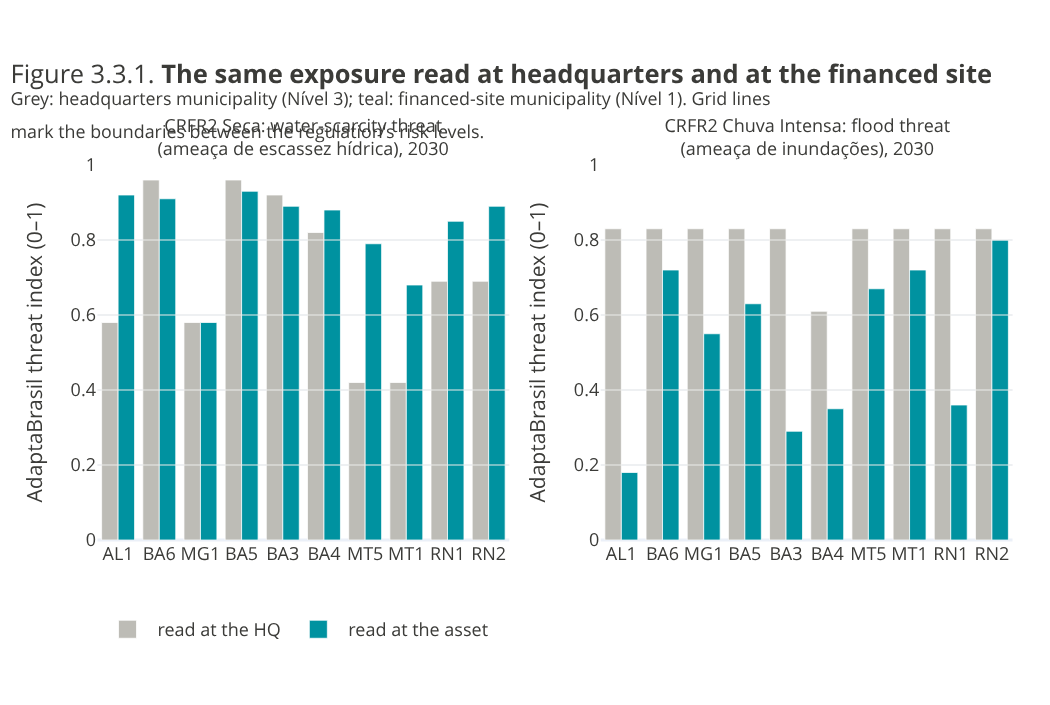

In [17]:
figure = bf.hq_vs_asset_bars(exposures, {"Seca": seca_hazard, "Chuva intensa": chuva_hazard})
bf.set_text(
    figure,
    title="The same exposure read at headquarters and at the financed site",
    subtitle=("Grey: headquarters municipality (Nível 3); teal: financed-site municipality "
              "(Nível 1). Grid lines mark the boundaries between the regulation's risk levels."),
    panels=("CRFR2 Seca: water-scarcity threat (ameaça de escassez hídrica), 2030",
            "CRFR2 Chuva Intensa: flood threat (ameaça de inundações), 2030"),
    y_titles="AdaptaBrasil threat index (0–1)")
bf.finalise(figure, "Figure 3.3.1")


**What this shows.** Filing at the sites moves R$ 290.4 M, 30% of gross exposure, to another macro-region. Intense-rain threat falls, as most headquarters are in state capitals and coastal cities with high urban-flood scores; drought threat rises at most sites. Section 4 moves from the municipality to each site's coordinates.


<a id="s4" name="s4"></a>

## 4. Hazards at financed sites

This section reads drought, water stress, flood and heat at the ten financed sites and places the readings beside AdaptaBrasil's municipal indicators. For each hazard, the first map gives national context and locates the sites; the next figure compares each site reading with its municipality. The two sources measure related but different quantities, so their colours and scores need not match.

The later tables and curves show the change across the available climate horizons. Table 4.1 lists the paired measures; Table 1.3.2 identifies their datasets. Section 5 considers which site signals can be translated into money.

**Table 4.1. Measures shown side by side in the maps.**

| Figures | Hazard | Alpha-Klima, at the site | AdaptaBrasil, in the municipality |
|---|---|---|---|
| 4.1.1–4.1.2 | Drought | 6-month mean SPEI at each site; map field shows the driest of the 1-, 3- and 6-month means | frequency of dry spells below −0.5 SPEI |
| 4.2.1–4.2.2 | Water stress | basin withdrawals over renewable supply | share of dry-season supply committed to farming and industry |
| 4.3.1–4.3.2 | Flood | river and coastal depth for a 1-in-100-year event | threat index for floods, flash floods and urban flooding |
| 4.4.1–4.4.2 | Heat | cooling degree days | number of heat waves |


In [18]:
rasters = br.load_hazard_maps(HAZARD_MAPS_FILE)
municipios = br.load_municipalities(MUNICIPALITIES_FILE)

adapta_maps = br.hazard_index_maps(rasters)

POINTS = assets[["id", "latitude", "longitude"]]
ak_curves = read_curves(br.asset_reading_requests(assets, rasters))
ak_assets = br.asset_readings(ak_curves, rasters)
map_assets = ak_assets.copy()
map_assets["drought"] = -ak_curves[ak_curves["family"] == "drought"].groupby("asset_id")["intensity"].min()
MAPS = dict(adapta=adapta_maps, rasters=rasters, municipalities=municipios, assets=assets, ak_assets=map_assets)


AdaptaBrasil 60044, 2050, scenario 41: 5570 municipalities | 1 without data
AdaptaBrasil 50103, 2050, scenario 36: 5570 municipalities | 1 without data


AdaptaBrasil 9, 2020, scenario null: 5570 municipalities | 0 without data
AdaptaBrasil 5047, 2017, scenario null: 5570 municipalities | 0 without data


<a id="s4-1" name="s4-1"></a>

### 4.1 Drought

SPEI starts with the climatic water balance (precipitation minus potential evapotranspiration), accumulated over 1, 3 or 6 months. The accumulated balance is converted to a historical percentile and then to a standard-normal score. Negative SPEI indicates drier-than-normal conditions; it is not a 0–1 probability. The site comparisons use the **6-month** historical mean. The national Alpha-Klima map instead shows the driest of the three window means at each grid cell, with its sign reversed so that larger plotted values indicate greater dryness. These are different summaries of the same historical dataset.

Figure 4.1.1 supplies national context and locates the sites using the map's mixed-window measure; Figure 4.1.2 compares each site's 6-month reading with its municipality's AdaptaBrasil indicator. The site series averages conditions, whereas AdaptaBrasil counts dry spells, so their rankings need not match.


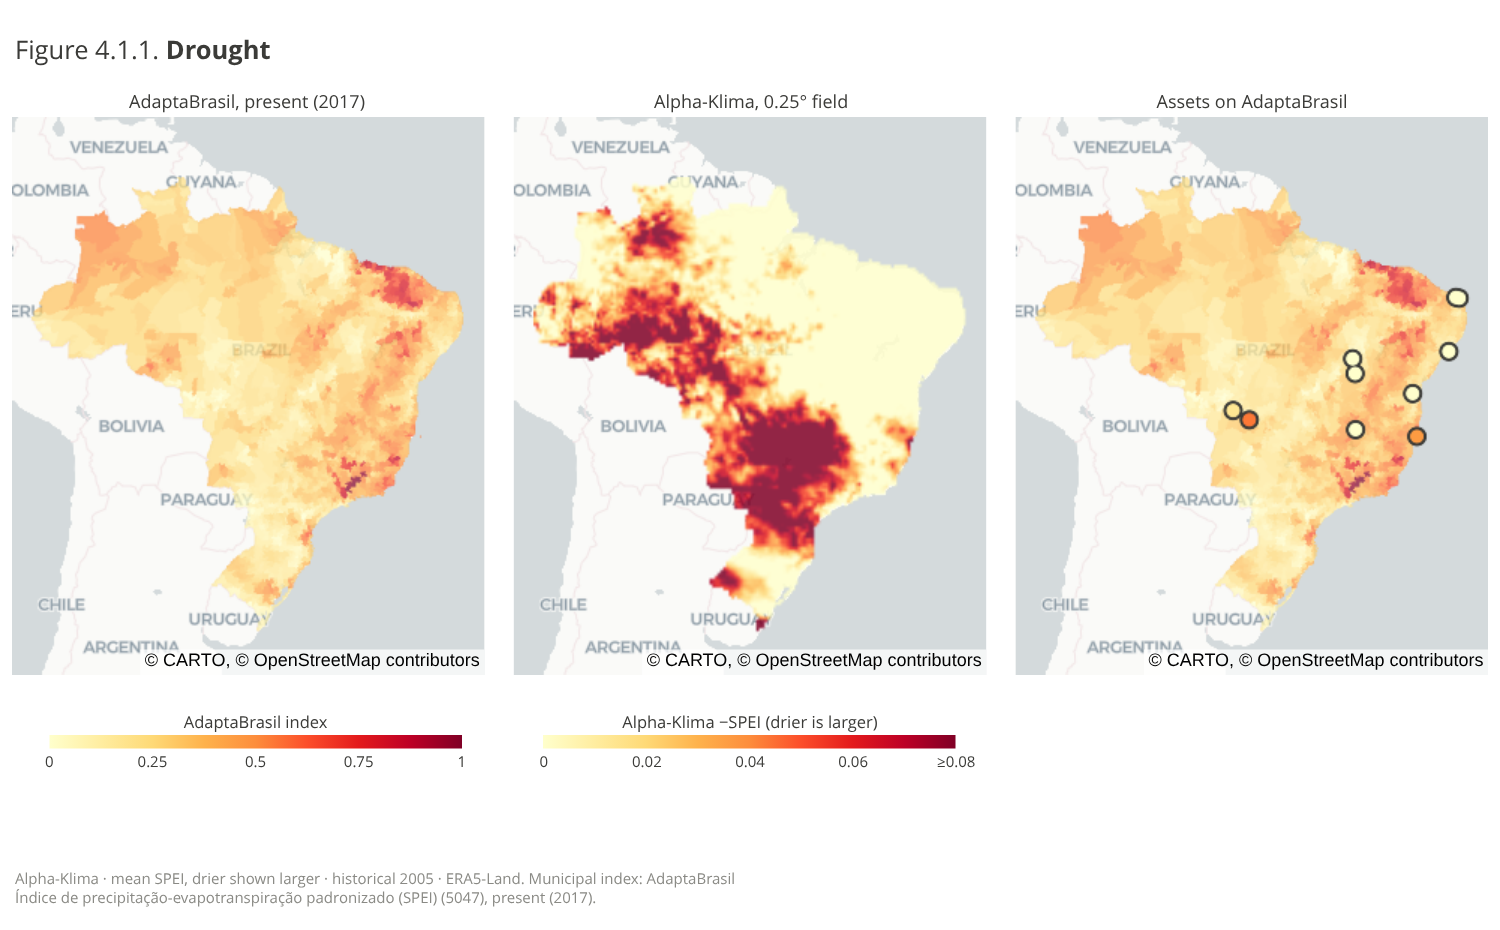

In [19]:
figure = bf.hazard_maps("drought", **MAPS)
bf.set_text(
    figure,
    title="Drought",
    panels=(f"AdaptaBrasil, {adapta_maps['drought'].attrs['horizon']}",
            f"Alpha-Klima, {rasters['drought'].step:g}° field",
            "Assets on AdaptaBrasil"))
bf.finalise(figure, "Figure 4.1.1", note=bf.source_note(rasters, "drought"))


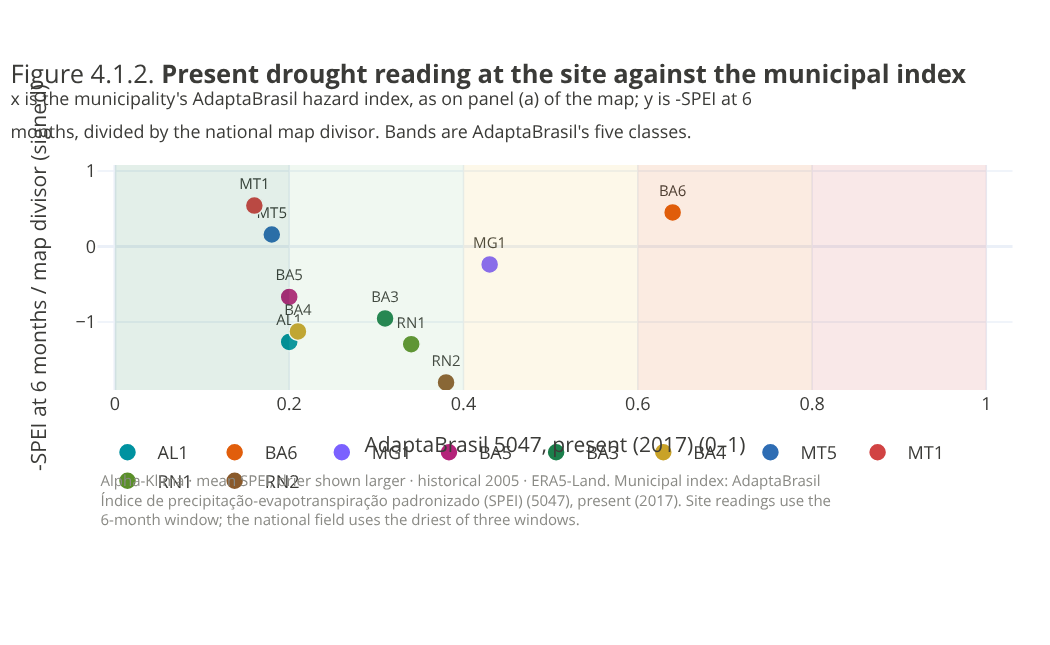

In [20]:
figure = bf.benchmark_vs_site_figure("drought", exposures, adapta_maps, ak_assets, rasters, COLOUR)
bf.set_text(
    figure,
    title="Present drought reading at the site against the municipal index",
    subtitle=("x is the municipality's AdaptaBrasil hazard index, as on panel (a) of the map; y is "
              "-SPEI at 6 months, divided by the national map divisor. Bands are "
              "AdaptaBrasil's five classes."),
    x_titles=(f"AdaptaBrasil {br.HAZARD_INDEX['drought']['indicator']}, "
              f"{adapta_maps['drought'].attrs['horizon']} (0–1)"),
    y_titles="-SPEI at 6 months / map divisor (signed)")
bf.finalise(figure, "Figure 4.1.2", note=bf.source_note(rasters, "drought", extra="Site readings use the 6-month window; the national field uses the driest of three windows"))


<a id="s4-2" name="s4-2"></a>

### 4.2 Water stress

Figure 4.2.1 maps the two water indicators and the sites; Figure 4.2.2 compares each site-basin reading with its municipality. WRI measures withdrawals against renewable supply under SSP5-8.5 in 2050. AdaptaBrasil measures the share of dry-season supply committed to farming and industry, so its higher scores at many sites do not imply comparable WRI water stress.


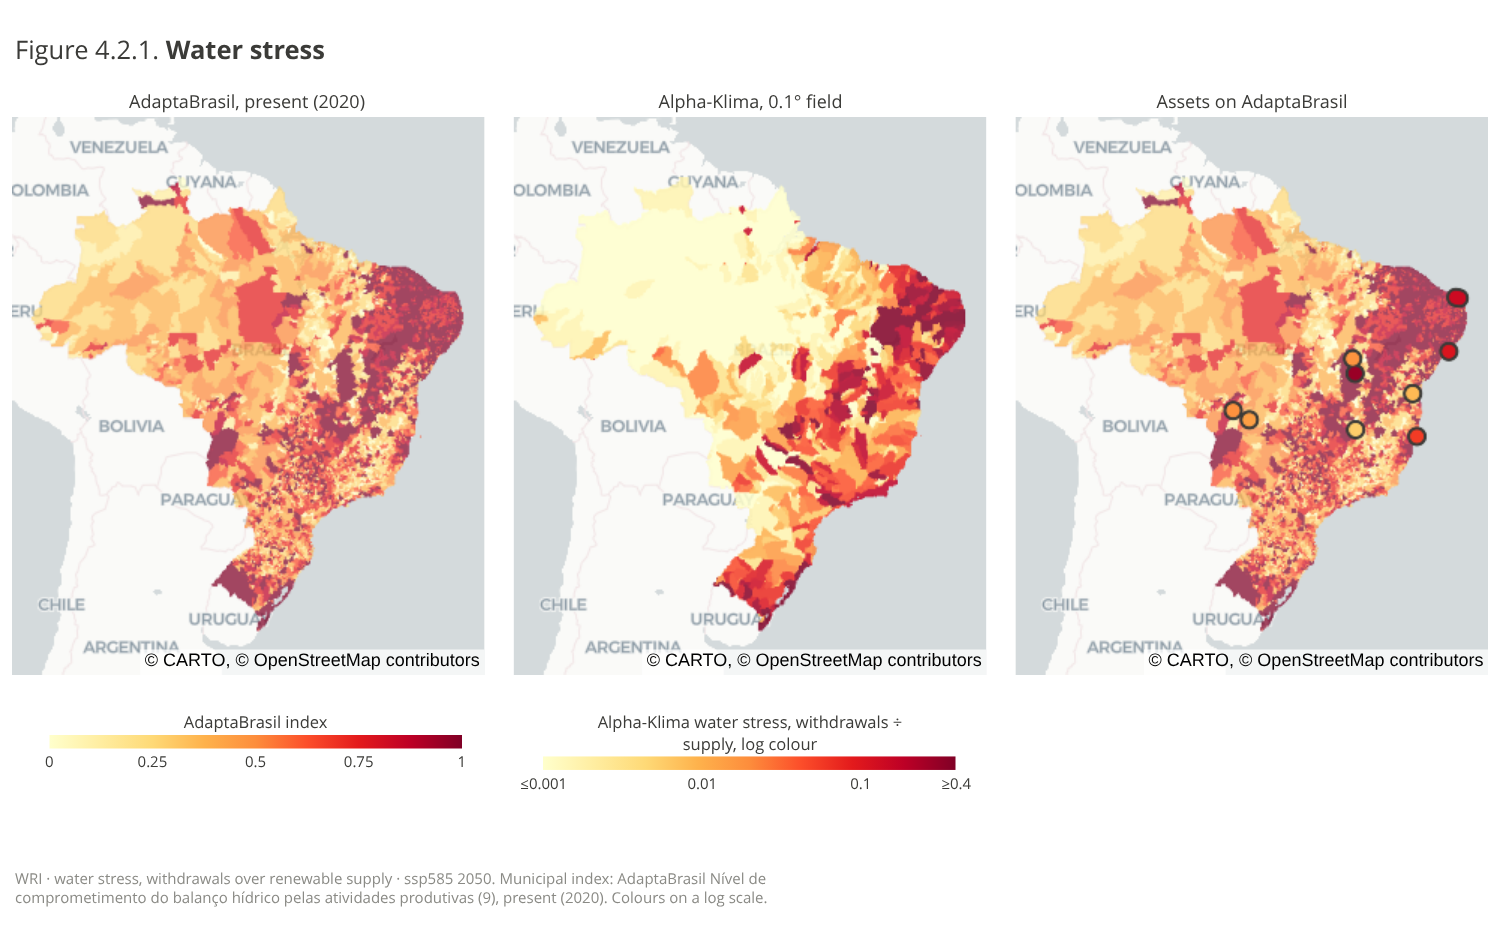

In [21]:
figure = bf.hazard_maps("water", **MAPS)
bf.set_text(
    figure,
    title="Water stress",
    panels=(f"AdaptaBrasil, {adapta_maps['water'].attrs['horizon']}",
            f"Alpha-Klima, {rasters['water'].step:g}° field",
            "Assets on AdaptaBrasil"))
bf.finalise(figure, "Figure 4.2.1", note=bf.source_note(rasters, "water"))


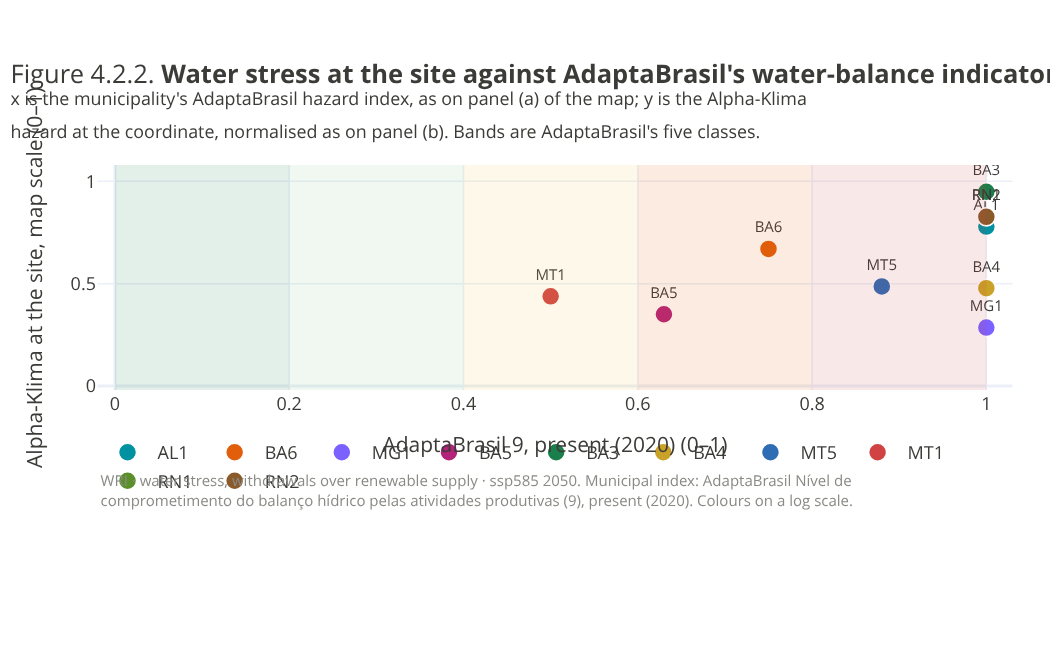

In [22]:
figure = bf.benchmark_vs_site_figure("water", exposures, adapta_maps, ak_assets, rasters, COLOUR)
bf.set_text(
    figure,
    title="Water stress at the site against AdaptaBrasil's water-balance indicator",
    subtitle=("x is the municipality's AdaptaBrasil hazard index, as on panel (a) of the map; y is "
              "the Alpha-Klima hazard at the coordinate, normalised as on panel (b). Bands are "
              "AdaptaBrasil's five classes."),
    x_titles=(f"AdaptaBrasil {br.HAZARD_INDEX['water']['indicator']}, "
              f"{adapta_maps['water'].attrs['horizon']} (0–1)"),
    y_titles="Alpha-Klima at the site, map scale (0–1)")
bf.finalise(figure, "Figure 4.2.2", note=bf.source_note(rasters, "water"))


<a id="s4-2-model" name="s4-2-model"></a>

#### 4.2.1 What the water measures show

WRI classes a withdrawals-to-supply ratio below 0.1 as low and above 0.8 as extremely high. By 2050, BA3 is medium–high, and AL1, RN1 and RN2 are low–medium; the other sites remain low. Six sites nevertheless reach the top of AdaptaBrasil indicator 9. Both readings describe a wider basin or municipality, not a site's own water use. Section 5 has no water-stress impact model.


<a id="s4-2-table" name="s4-2-table"></a>

#### 4.2.2 Water stress through 2050

Table 4.2.1 follows site-basin water stress from the historical baseline to the available SSP5-8.5 horizons. Read the WRI class together with the change: a large percentage increase from a low baseline can remain within the low class. The source provides no comparable 2080 or lower-emission series for this exercise.


In [23]:
water_stress_df = read_curves([
    br.curve_request(WATER_STRESS[0], WATER_STRESS[1], WATER_STRESS_PATH, scenario, year, POINTS,
                     key="water_stress", indicator=WATER_STRESS[1])
    for scenario, year in br.comparison_combos(COMPARE["water_stress"])])
print(f"water stress: {len(water_stress_df)} readings")


water stress: 30 readings


In [24]:
entry = COMPARE["water_stress"]
ws = water_stress_df.pivot_table(index="asset_id", columns=["scenario", "year"], values="intensity", aggfunc="first")
base, last = ws[entry["baseline"]], ws[entry["compared"][-1]]

def wri_class(values):
    return pd.cut(values, [-np.inf, 0.1, 0.2, 0.4, 0.8, np.inf], right=False,
                  labels=["Low", "Low–medium", "Medium–high", "High", "Extremely high"]).astype(str)

table = pd.DataFrame({f"{entry['baseline'][1]} (baseline)": base,
                      **{f"{br.label(s)} {y}": ws[(s, y)] for s, y in entry["compared"]}}).round(3)
table["change (%)"] = ((last / base - 1) * 100).round()
table["WRI class"] = wri_class(base) + " → " + wri_class(last)
display(bf.table(
    table.rename_axis("Site"),
    f"Table 4.2.1. Water stress at each site, withdrawals over renewable supply: the "
    f"{entry['baseline'][1]} baseline against each compared horizon"))


,1999 (baseline),SSP5-8.5 2030,SSP5-8.5 2050,change (%),WRI class
Site,,,,,
AL1,0.024,0.041,0.106,336,Low → Low–medium
BA3,0.277,0.314,0.295,7,Medium–high → Medium–high
BA4,0.021,0.021,0.018,-17,Low → Low
BA5,0.004,0.006,0.008,96,Low → Low
BA6,0.023,0.034,0.055,137,Low → Low
MG1,0.002,0.004,0.006,131,Low → Low
MT1,0.008,0.012,0.014,63,Low → Low
MT5,0.013,0.016,0.018,44,Low → Low
RN1,0.103,0.13,0.142,37,Low–medium → Low–medium


<a id="s4-3" name="s4-3"></a>

### 4.3 Flood

Figure 4.3.1 maps municipal flood threat beside modelled river or coastal depth; Figure 4.3.2 compares the readings at the sites. The municipal index includes flash and urban flooding, whereas the site depth comes from river and coastal models. A high municipal score does not establish water at a building, and a low score does not exclude it.

The depth curves that follow refer to the ground of the model cell. Section 4.3.3 moves them to each site's own ground.


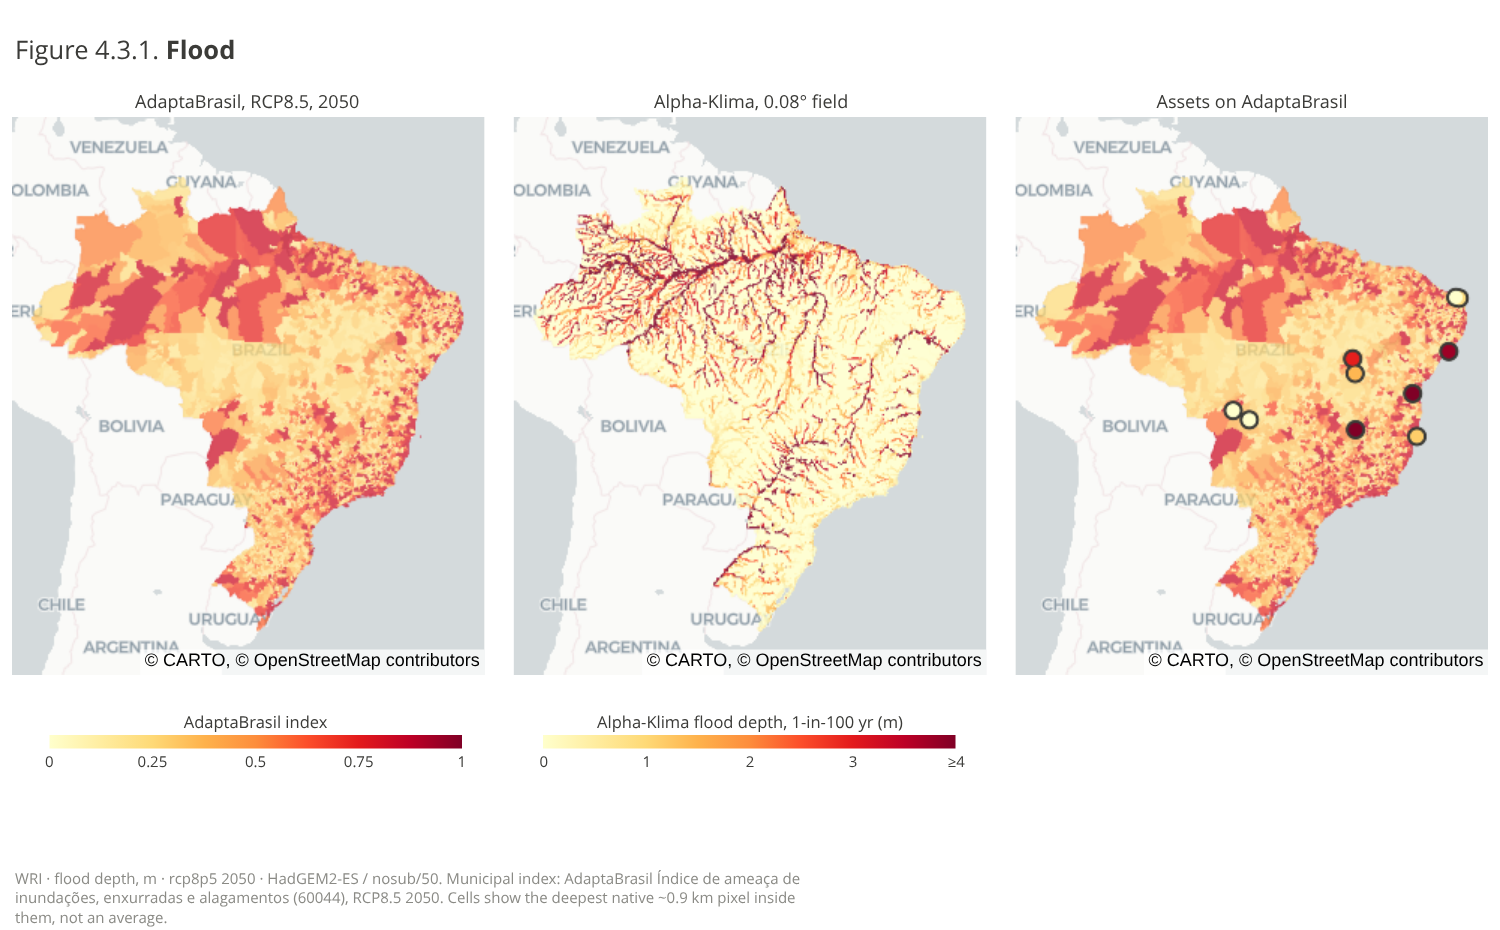

In [25]:
figure = bf.hazard_maps("flood", **MAPS)
bf.set_text(
    figure,
    title="Flood",
    panels=(f"AdaptaBrasil, {adapta_maps['flood'].attrs['horizon']}",
            f"Alpha-Klima, {rasters['flood'].step:g}° field",
            "Assets on AdaptaBrasil"))
bf.finalise(figure, "Figure 4.3.1", note=bf.source_note(rasters, "flood"))


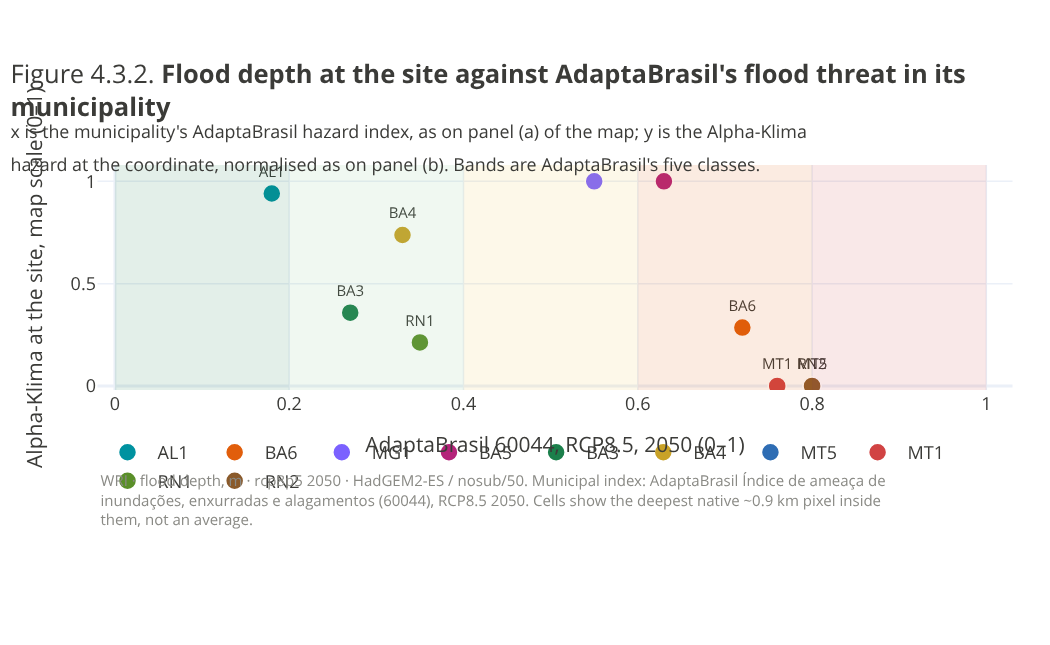

In [26]:
figure = bf.benchmark_vs_site_figure("flood", exposures, adapta_maps, ak_assets, rasters, COLOUR)
bf.set_text(
    figure,
    title="Flood depth at the site against AdaptaBrasil's flood threat in its municipality",
    subtitle=("x is the municipality's AdaptaBrasil hazard index, as on panel (a) of the map; y is "
              "the Alpha-Klima hazard at the coordinate, normalised as on panel (b). Bands are "
              "AdaptaBrasil's five classes."),
    x_titles=(f"AdaptaBrasil {br.HAZARD_INDEX['flood']['indicator']}, "
              f"{adapta_maps['flood'].attrs['horizon']} (0–1)"),
    y_titles="Alpha-Klima at the site, map scale (0–1)")
bf.finalise(figure, "Figure 4.3.2", note=bf.source_note(rasters, "flood"))


<a id="s4-3-model" name="s4-3-model"></a>

#### 4.3.1 Flood depth

WRI estimates flood depth on a grid of roughly 1 km. A return period expresses the annual chance of a depth being reached or exceeded: a 1-in-100-year depth has a 1% annual chance. The dataset excludes local defences and site-level terrain, which must be added separately.


<a id="s4-3-curves" name="s4-3-curves"></a>

#### 4.3.2 Flood frequency curves

Figure 4.3.3 plots depth against return period at each flood site. At a fixed depth, the horizontal distance between curves shows how often that flood occurs in another climate slice; Section 7 uses this change. Frequencies beyond the published 2–1,000-year range are bounds.


In [27]:
FLOOD_POINTS = {family: POINTS[[family in kinds for kinds in assets["hazards"]]] for family in FLOOD_FAMILIES}
flood_requests = [
    br.curve_request(r["hazard_type"], r["indicator_id"], r["path"], scenario, year, FLOOD_POINTS[family],
                     family=family, resource=r["label"], is_baseline=r["is_baseline"],
                     subsidence=r.get("subsidence"), percentile=r.get("percentile"), gcm=r.get("gcm"))
    for family, r in FLOOD_LAYERS
    for scenario, year in ([("historical", 1980)] if r["is_baseline"] else
                           [(s, y) for s in FLOOD_SCENARIOS[family] for y in FLOOD_YEARS[family]])]
flood_df = (read_curves(flood_requests).rename(columns={"index_value": "return_period", "intensity": "depth"})
            .drop(columns=["request_item_id", "index_name", "source_path"]))
print(f"flood: {len(flood_requests)} requests -> {len(flood_df)} depths")
flood_df.groupby(["family", "resource"])["asset_id"].nunique()


flood: 27 requests -> 558 depths


family    resource      
coastal   baseline nosub    2
          nosub 5%          2
          nosub 50%         2
          nosub 95%         2
          wtsub 50%         2
riverine  HadGEM2-ES        6
Name: asset_id, dtype: int64

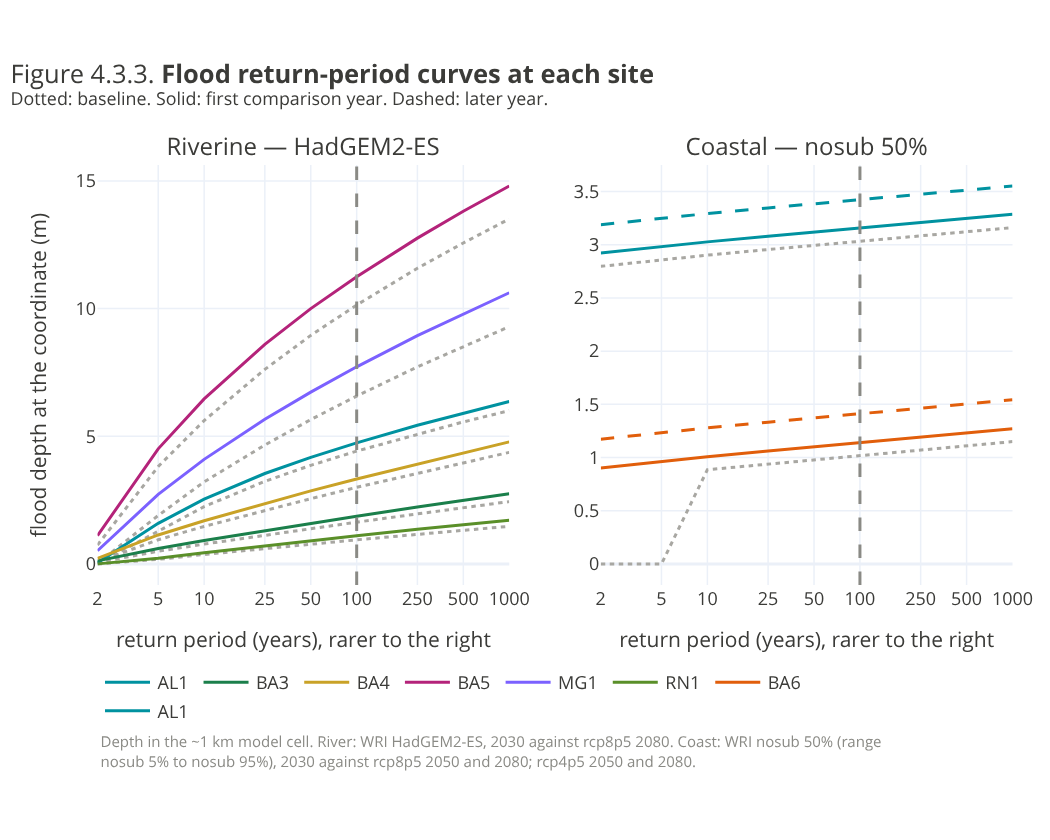

In [28]:
figure = bf.return_period_figure(
    flood_df, COLOUR, scenario=FOCUS_SCENARIO, year=FOCUS_YEAR, focus_rp=FOCUS_RP,
    river_model=RIVER_MODEL, coastal_resource=COASTAL_RESOURCE,
    river_baseline_year=BASELINE_YEAR, coastal_baseline_year=BASELINE_YEAR,
    comparison_years=COMPARISON_YEARS_BY_FAMILY)
bf.set_text(
    figure,
    title="Flood return-period curves at each site",
    x_titles="return period (years), rarer to the right",
    y_titles=("flood depth at the coordinate (m)", ""))
bf.finalise(figure, "Figure 4.3.3", note=f"Depth in the ~1 km model cell. {FLOOD_READING}")


<a id="s4-3-site" name="s4-3-site"></a>

#### 4.3.3 From grid cell to site

Table 4.3.1 and Figure 4.3.4 take each site's elevation above the model cell off the cell depth, leaving the water on the site's own ground. At BA5 the 2030 1-in-100-year flood falls from 10.14 m in the cell to 3.14 m on the site.

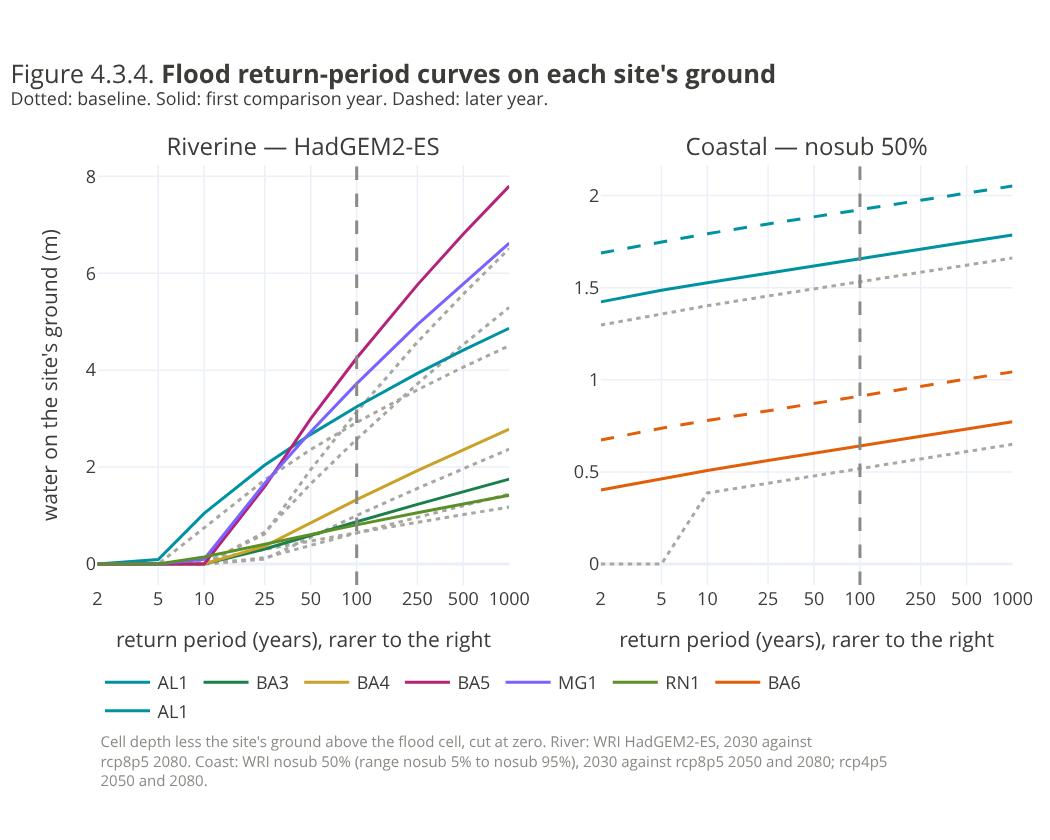

In [29]:
site_flood_df = br.site_flood_depths(flood_df, assets)
flood_steps = br.flood_depth_steps(flood_df, assets, scenario=FOCUS_SCENARIO, return_period=FOCUS_RP,
                                   years=FLOOD_YEARS, river_model=RIVER_MODEL,
                                   coastal_resource=COASTAL_RESOURCE)

ladder = flood_steps.pivot_table(index=["family", "asset_id"], columns="year",
                                 values=["cell_depth", "site_depth"])
ladder = ladder.rename(columns={"cell_depth": "in the model cell (m)",
                                "site_depth": "at the site (m)"}, level=0)
ladder.insert(0, ("ground above the flood cell (m)", ""),
              flood_steps.groupby(["family", "asset_id"])["site_elevation"].first())
display(bf.table(
    ladder.round(2).astype(object).where(ladder.notna(), "—")
    .rename_axis(index=["Family", "Site"], columns=[None, None]),
    f"Table 4.3.1. The 1-in-{FOCUS_RP:.0f}-year flood in the model cell and on the site's "
    f"ground, {FOCUS_SCENARIO}, by year"))

figure = bf.return_period_figure(
    site_flood_df, COLOUR, scenario=FOCUS_SCENARIO, year=FOCUS_YEAR, focus_rp=FOCUS_RP,
    river_model=RIVER_MODEL, coastal_resource=COASTAL_RESOURCE,
    river_baseline_year=BASELINE_YEAR, coastal_baseline_year=BASELINE_YEAR,
    comparison_years=COMPARISON_YEARS_BY_FAMILY)
bf.set_text(
    figure,
    title="Flood return-period curves on each site's ground",
    x_titles="return period (years), rarer to the right",
    y_titles=("water on the site's ground (m)", ""))
bf.finalise(
    figure, "Figure 4.3.4",
    note=f"Cell depth less the site's ground above the flood cell, cut at zero. {FLOOD_READING}")


<a id="s4-4" name="s4-4"></a>

### 4.4 Heat

Figure 4.4.1 maps municipal heat-wave counts and site cooling degree days; Figure 4.4.2 compares the two at the ten sites, and Figure 4.4.3 follows the site indicators from the historical baseline to 2030 and 2050.


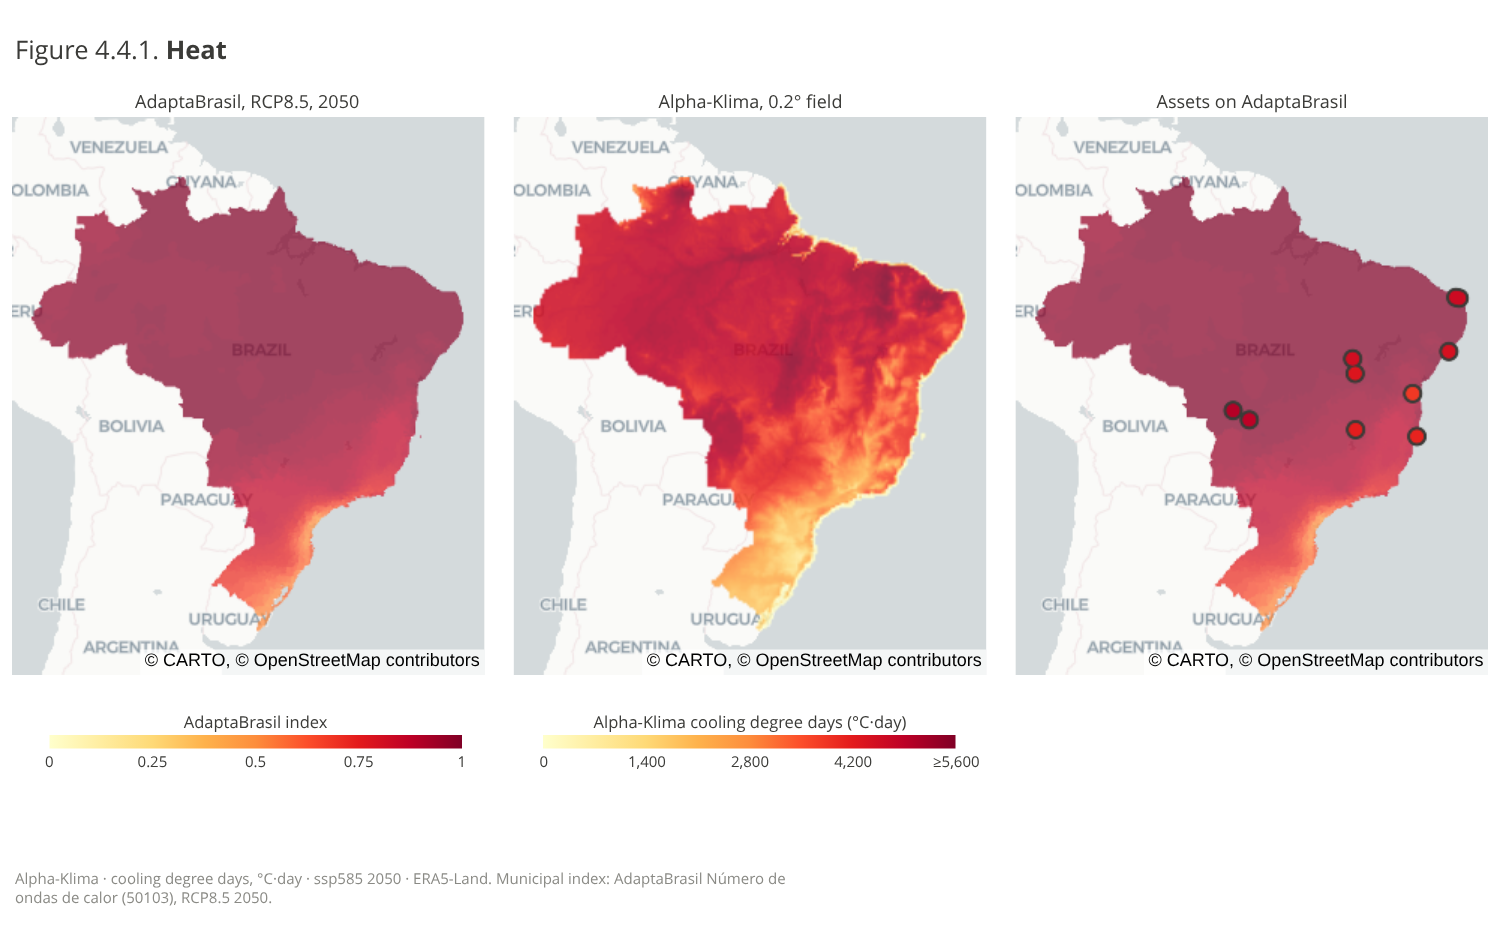

In [30]:
figure = bf.hazard_maps("heat", **MAPS)
bf.set_text(
    figure,
    title="Heat",
    panels=(f"AdaptaBrasil, {adapta_maps['heat'].attrs['horizon']}",
            f"Alpha-Klima, {rasters['heat'].step:g}° field",
            "Assets on AdaptaBrasil"))
bf.finalise(figure, "Figure 4.4.1", note=bf.source_note(rasters, "heat"))


<a id="s4-4-model" name="s4-4-model"></a>

#### 4.4.1 Heat indicators

Cooling degree days describe cooling demand; days above a WBGT threshold indicate stressful outdoor work; work-loss estimates describe lost working capacity. They use different thresholds and do not measure conditions inside a particular building. Section 5.4 also uses degree days above 32 °C to estimate working-time loss at industrial sites.


<a id="s4-4-compare" name="s4-4-compare"></a>

#### 4.4.2 Site heat and the municipal index

Figure 4.4.2 compares site cooling degree days with the 2050 municipal heat-wave index. The index is near its maximum across the sites and barely distinguishes them; the site readings vary more.


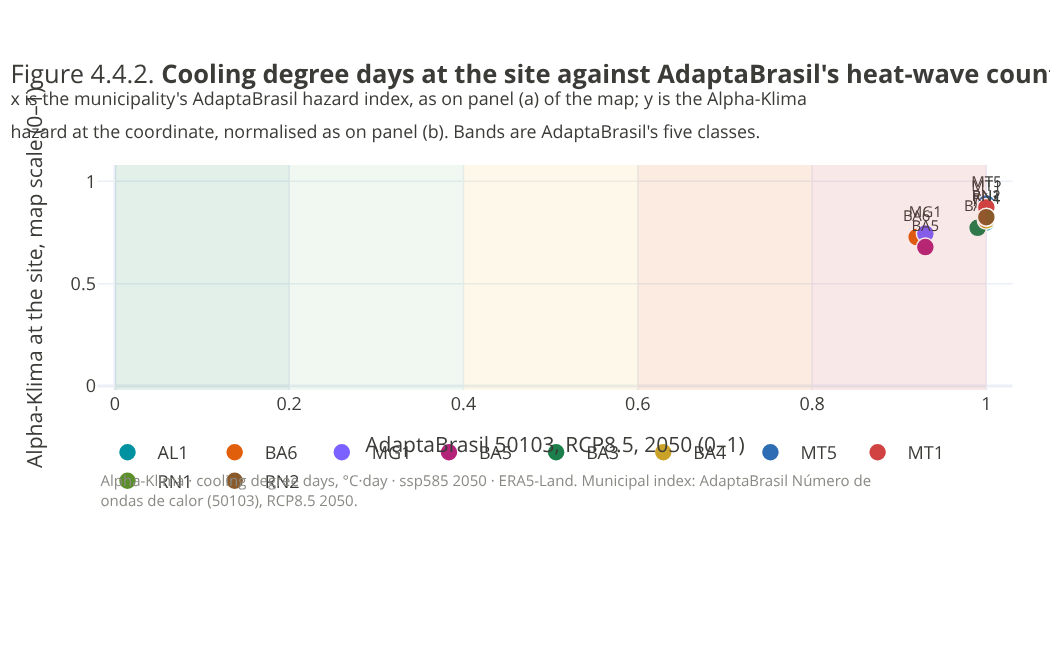

In [31]:
figure = bf.benchmark_vs_site_figure("heat", exposures, adapta_maps, ak_assets, rasters, COLOUR)
bf.set_text(
    figure,
    title="Cooling degree days at the site against AdaptaBrasil's heat-wave count",
    subtitle=("x is the municipality's AdaptaBrasil hazard index, as on panel (a) of the map; y is "
              "the Alpha-Klima hazard at the coordinate, normalised as on panel (b). Bands are "
              "AdaptaBrasil's five classes."),
    x_titles=(f"AdaptaBrasil {br.HAZARD_INDEX['heat']['indicator']}, "
              f"{adapta_maps['heat'].attrs['horizon']} (0–1)"),
    y_titles="Alpha-Klima at the site, map scale (0–1)")
bf.finalise(figure, "Figure 4.4.2", note=bf.source_note(rasters, "heat"))


<a id="s4-4-indicators" name="s4-4-indicators"></a>

#### 4.4.3 Air-temperature indicators

Figure 4.4.3 shows the historical baseline and the SSP2-4.5 and SSP5-8.5 readings through 2050. The pathways separate more clearly by 2050. Work loss is read on NorESM2-MM at low, medium and high work intensity, one line per site; heavy work approaches the model ceiling at the hottest sites, which limits the change it can show.


In [32]:
HEAT_SERIES = ([(key, spec, {}) for key, spec in CHRONIC_HEAT.items()]
               + [("work_loss", spec, {"work_intensity": intensity}) for intensity, spec in WORK_LOSS.items()])
chronic_heat_df = (read_curves([br.curve_request(hazard_type, indicator, HEAT_PATHS[indicator], scenario, year,
                                                 POINTS, key=key, indicator=indicator, **tags)
                                for key, (hazard_type, indicator, _), tags in HEAT_SERIES
                                for scenario, year in HEAT_COMBOS])
                   .rename(columns={"index_value": "threshold", "intensity": "value"})
                   .drop(columns=["request_item_id", "source_path"]))
at_sea = chronic_heat_df.groupby(["key", "asset_id"])["value"].apply(lambda values: values.fillna(0).eq(0).all())
assert not at_sea.any(), (f"heat reads zero everywhere at {list(at_sea[at_sea].index)}: the grid likely "
                          "treats the cell as sea; move the point inland")
print(f"heat: {len(chronic_heat_df)} readings")


heat: 1150 readings


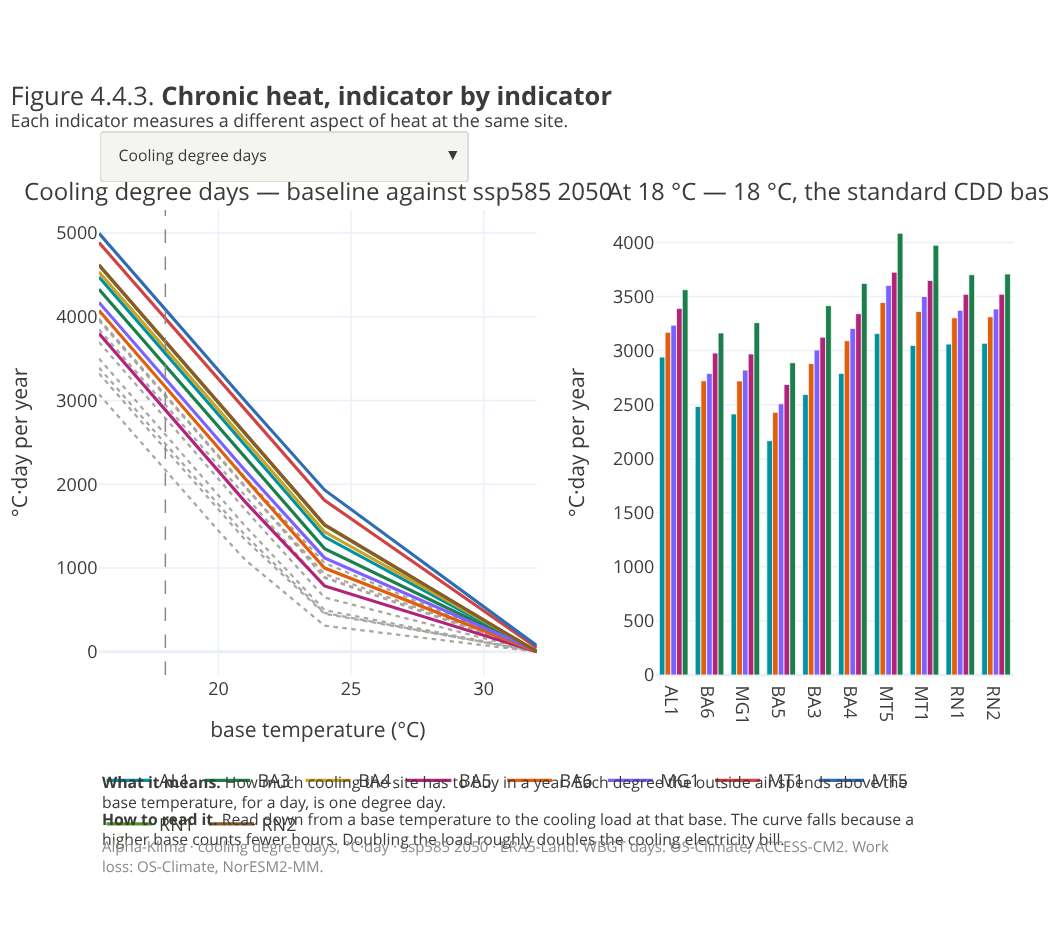

In [33]:
HEAT_PANEL = ["baseline", *(f"{scenario} {year}" for year in HEAT_YEARS for scenario in HEAT_SCENARIOS)]
figure = bf.chronic_heat_figure(chronic_heat_df, ASSET_IDS, COLOUR, horizons=HEAT_PANEL,
                                focus_horizon=FOCUS_HEAT)
bf.set_text(
    figure,
    title="Chronic heat, indicator by indicator",
    subtitle="Each indicator measures a different aspect of heat at the same site.")
bf.finalise(
    figure, "Figure 4.4.3",
    note=bf.source_note(rasters, "heat", include_index=False,
                        extra=(f"WBGT days: OS-Climate, {CHRONIC_HEAT['wbgt'][2]}. "
                               f"Work loss: OS-Climate, {WORK_LOSS_MODEL}")))


<a id="s4-4-water" name="s4-4-water"></a>

#### 4.4.4 Warm river water

Table 4.4.1 counts weeks above 30 °C at each site. Weeks increase under both pathways, generally more under RCP8.5. The threshold is illustrative, and the exercise does not price a warm-water impact.


In [34]:
warm_water_df = read_curves([
    br.curve_request(WARM_WATER[0], WARM_WATER[1], WARM_WATER_PATH, scenario, year, POINTS,
                     key="warm_water", indicator=WARM_WATER[1])
    for scenario, year in br.comparison_combos(COMPARE["warm_water"])])
print(f"warm water: {len(warm_water_df)} readings")


warm water: 900 readings


In [35]:
entry = COMPARE["warm_water"]
at = warm_water_df[np.isclose(warm_water_df["index_value"].astype(float), WARM_WATER_THRESHOLD)]
ww = at.pivot_table(index="asset_id", columns=["scenario", "year"], values="intensity", aggfunc="first")
pathways = list(dict.fromkeys(scenario for scenario, _ in entry["compared"]))
table = (ww[pathways]
         .rename(columns=br.label, level="scenario")
         .rename(columns=lambda y: f"{y} (baseline)" if y == entry["baseline"] else str(y), level="year")
         .rename_axis(index="Site", columns=["Pathway", "Year"]))
display(bf.table(
    table.round(1),
    f"Table 4.4.1. Weeks a year the river water is warmer than {WARM_WATER_THRESHOLD:g} °C, "
    f"Utrecht HadGEM2-ES run: {BASELINE_YEAR} and each compared year, by pathway"))


<a id="s4-5" name="s4-5"></a>

### 4.5 Coastal flood

AL1 and BA6 have coastal flood readings. Figure 4.5.1 shows the depth that sea-level rise adds and its range, Figure 4.5.2 the depth added by land subsidence, and Figure 4.5.3 the combined depth against the site's ground, one site at a time.


<a id="s4-5-model" name="s4-5-model"></a>

#### 4.5.1 Coastal flood depth

The WRI coastal layer estimates water depth in the site's grid cell. The median sea-level estimate is the headline; the 5th and 95th percentiles give the published range, and the subsidence variant adds sinking land. The grid does not represent local defences, shoreline retreat or building-level drainage.


<a id="s4-5-1" name="s4-5-1"></a>

#### 4.5.2 Sea-level rise

Table 4.5.1 and Figure 4.5.1 compare projected coastal depth with the observed run. At both sites the added depth and its range grow across the horizons: by 2080 under RCP8.5, the median adds about 0.52 m, and the 5th–95th percentile range spans 0.34 m at AL1 and 0.40 m at BA6.


In [36]:
coastal_parts = br.coastal_split(flood_df, FOCUS_RP, main=COASTAL_RESOURCE, low=COASTAL_RANGE[0],
                                 high=COASTAL_RANGE[1], subsidence=COASTAL_SUBSIDENCE)

display(bf.table(
    coastal_parts.set_index(["asset_id", "scenario", "year"]).round(3)
    .rename_axis(index=["Site", "Pathway", "Year"], columns=None)
    .rename(columns={"baseline_depth": "Observed depth",
                     "projected_depth": f"Projected, {COASTAL_RESOURCE}",
                     "low_depth": f"Projected, {COASTAL_RANGE[0]}",
                     "high_depth": f"Projected, {COASTAL_RANGE[1]}",
                     "sea_level_rise": "Sea-level rise", "subsidence": "Subsidence",
                     "projection_spread": "Projection spread"}),
    f"Table 4.5.1. Coastal decomposition at the 1-in-{FOCUS_RP:.0f}-year event (m): sea-level "
    f"rise is {COASTAL_RESOURCE} against the observed run, with the {COASTAL_RANGE[0]} to "
    f"{COASTAL_RANGE[1]} range; land subsidence is {COASTAL_SUBSIDENCE} less "
    f"{COASTAL_RESOURCE}"))


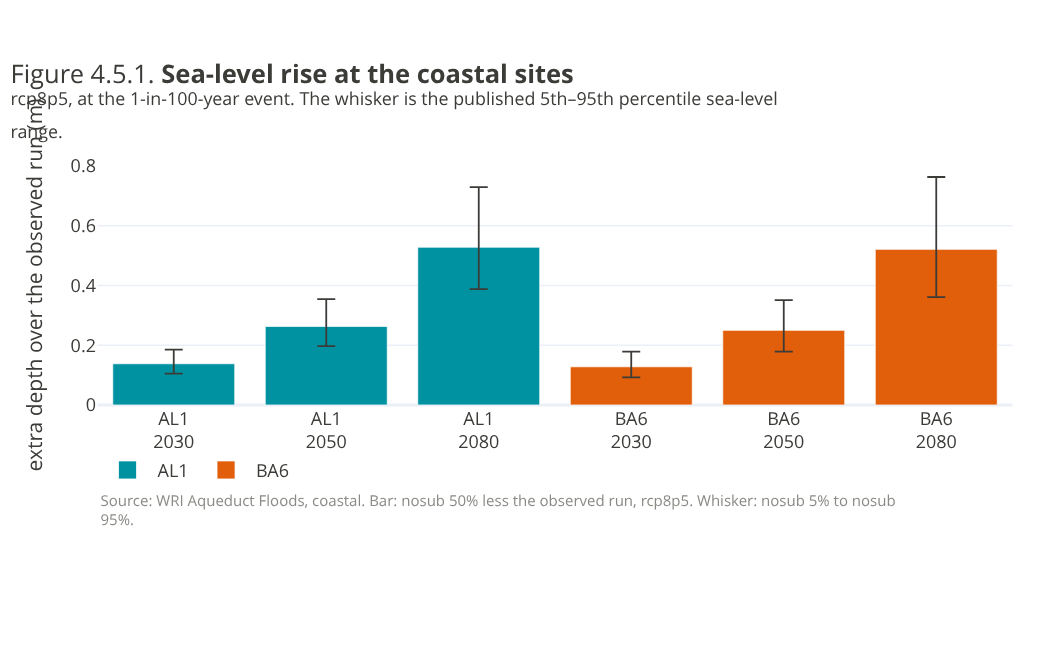

In [37]:
figure = bf.sea_level_figure(coastal_parts, COLOUR, scenario=FOCUS_SCENARIO,
                             return_period=FOCUS_RP)
bf.set_text(
    figure,
    title="Sea-level rise at the coastal sites",
    subtitle=(f"{FOCUS_SCENARIO}, at the 1-in-{FOCUS_RP:.0f}-year event. The whisker is the "
              "published 5th–95th percentile sea-level range."),
    y_titles="extra depth over the observed run (m)")
bf.finalise(
    figure, "Figure 4.5.1",
    note=(f"Source: WRI Aqueduct Floods, coastal. Bar: {COASTAL_RESOURCE} less the observed run, "
          f"{FOCUS_SCENARIO}. Whisker: {COASTAL_RANGE[0]} to {COASTAL_RANGE[1]}."))


<a id="s4-5-2" name="s4-5-2"></a>

#### 4.5.3 Land subsidence

Figure 4.5.2 shows the additional coastal depth in the subsidence variant: at most 0.06 m at AL1 and zero at BA6. It is a difference between modelled layers, not a site-level subsidence survey.


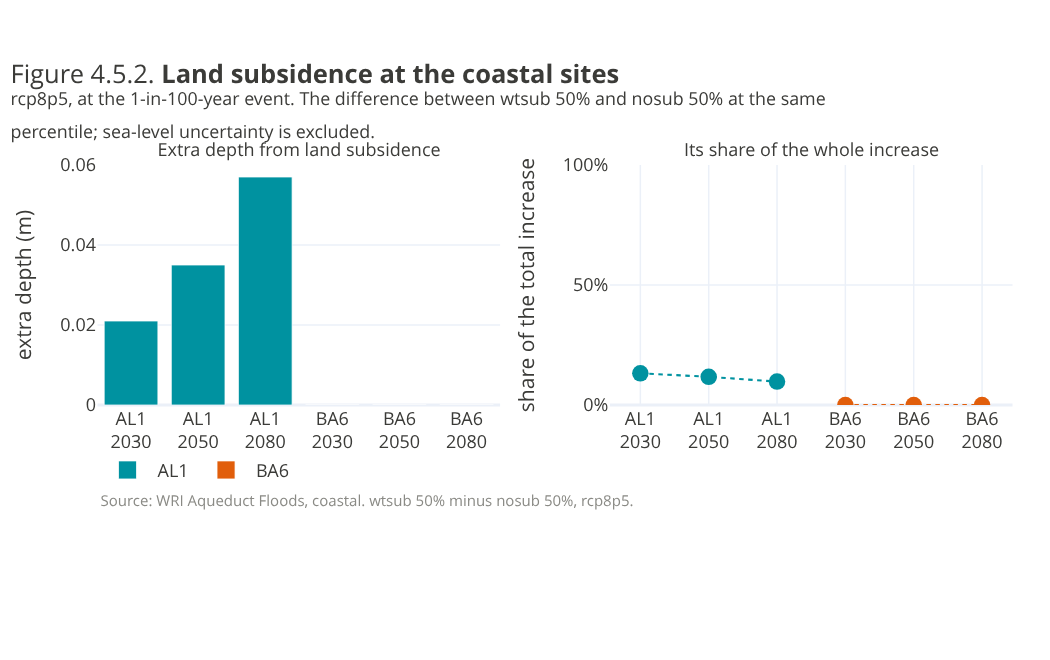

In [38]:
figure = bf.subsidence_figure(coastal_parts, COLOUR, scenario=FOCUS_SCENARIO,
                              return_period=FOCUS_RP, main=COASTAL_RESOURCE,
                              subsidence=COASTAL_SUBSIDENCE)
bf.set_text(
    figure,
    title="Land subsidence at the coastal sites",
    subtitle=(f"{FOCUS_SCENARIO}, at the 1-in-{FOCUS_RP:.0f}-year event. The difference between "
              f"{COASTAL_SUBSIDENCE} and {COASTAL_RESOURCE} at the same percentile; sea-level "
              "uncertainty is excluded."),
    panels=("Extra depth from land subsidence", "Its share of the whole increase"),
    y_titles=("extra depth (m)", "share of the total increase"))
bf.finalise(
    figure, "Figure 4.5.2",
    note=(f"Source: WRI Aqueduct Floods, coastal. {COASTAL_SUBSIDENCE} minus "
          f"{COASTAL_RESOURCE}, {FOCUS_SCENARIO}."))


<a id="s4-5-3" name="s4-5-3"></a>

#### 4.5.4 Combined coastal depth

Figure 4.5.3 builds from the observed depth through sea-level rise and subsidence and compares the total with the site's ground. It shows whether the modelled water reaches the site, not the expected damage.


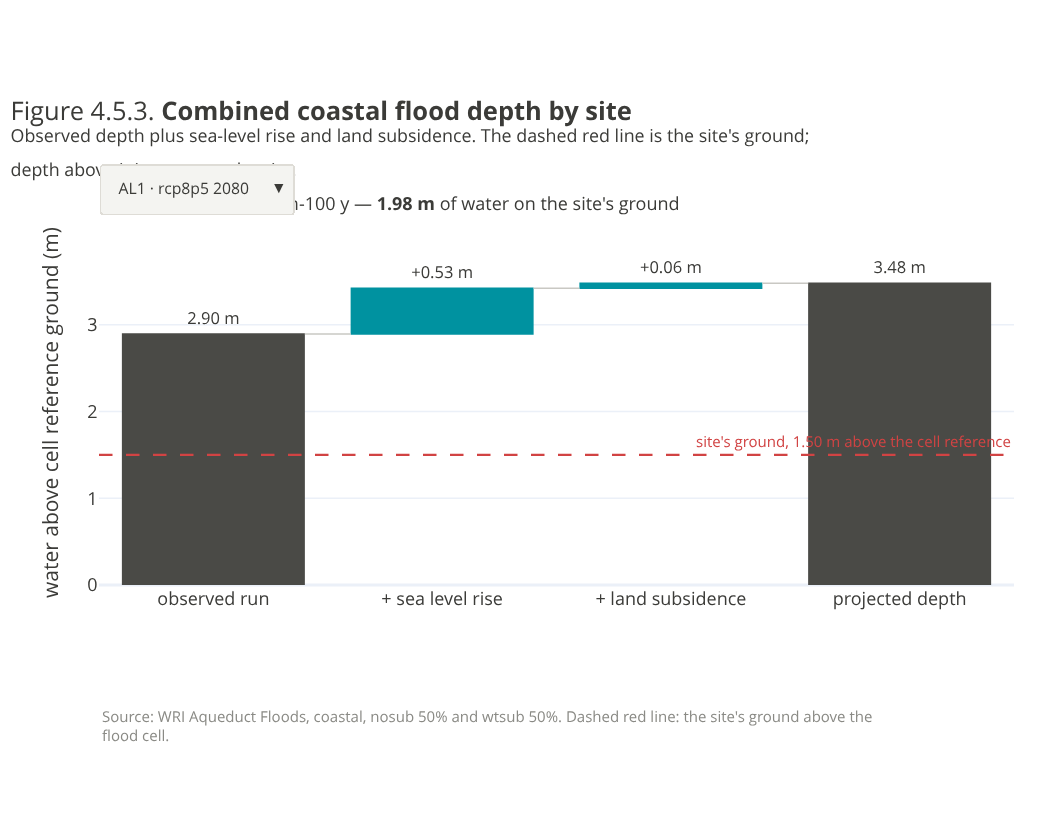

In [39]:
figure = bf.coastal_combined_figure(coastal_parts, assets, return_period=FOCUS_RP,
                                    scenario=FOCUS_SCENARIO,
                                    year=max(COMPARISON_YEARS_BY_FAMILY["coastal"]))
bf.set_text(
    figure,
    title="Combined coastal flood depth by site",
    subtitle=("Observed depth plus sea-level rise and land subsidence. The dashed red line is the "
              "site's ground; depth above it is water on the site."),
    y_titles="water above cell reference ground (m)")
bf.finalise(
    figure, "Figure 4.5.3",
    note=(f"Source: WRI Aqueduct Floods, coastal, {COASTAL_RESOURCE} and "
          f"{COASTAL_SUBSIDENCE}. Dashed red line: the site's ground above the flood cell."))


**What the site results show.** The paired maps give national context, but site readings change the picture for this book. Several sites in high-scoring municipalities have no modelled flood depth at their coordinates, while AL1 has substantial coastal depth despite a low municipal intense-rain score. River floods become 1.5–2.2 times as frequent by 2080 and coastal floods 8–9 times as frequent by 2050. Drought has only a historical site reading. Section 5 prices neither drought nor warm river water; water stress remains a Section 4 indicator.


<a id="s5" name="s5"></a>

## 5. Which climate events become financial impacts

A hazard reading becomes money through a vulnerability model. The model turns the hazard's intensity at a site into a damage fraction, a share of working time lost or extra energy use, which is then multiplied by the site's value, labour cost or electricity tariff. Each model is built on one hazard indicator, with its own variable, unit, reference level and period, and it must be fed that indicator: a damage curve read on water depth in metres cannot take a municipal threat index. Where no model matches a hazard's indicator, the hazard stays unpriced, which does not mean it causes no loss. Every amount is a change over the baseline of its own source.

<a id="s5-1" name="s5-1"></a>

### 5.1 River flood damage

The river damage estimates use the depth in the model cell, shown in Figure 4.3.3; the water on the site's ground (Section 4.3.3) is a screening view and does not reprice it. Table 5.3.1 and Figures 5.3.1–5.3.2 show the damage fraction, expected annual damage and value at risk for the six river sites in 2030 and 2080.


In [40]:
flood_sites = assets[[bool({"riverine", "coastal"} & set(kinds)) for kinds in assets["hazards"]]]
DAMAGE_PATHS = {"RiverineInundation": {"flood_depth": FLOOD_PATHS[RIVER_MODEL]},
                "CoastalInundation": {"flood_depth": FLOOD_PATHS[COASTAL_RESOURCE]}}
flood_damage = impacts(flood_sites, {"RiverineInundation": ["flood_depth"], "CoastalInundation": ["flood_depth"]},
                       [FOCUS_SCENARIO], [BASELINE_YEAR, *COMPARISON_YEARS], DAMAGE_PATHS)
flood_damage = pd.concat([
    br.flood_damage_rows(flood_damage, assets, family=family, scenario=FOCUS_SCENARIO,
                         years=(BASELINE_YEAR, *COMPARISON_YEARS_BY_FAMILY[family]))
    for family in FLOOD_FAMILIES], ignore_index=True)
flood_damage = br.river_damage_on_depth(flood_damage, flood_steps, scenario=FOCUS_SCENARIO,
                                        baseline_year=BASELINE_YEAR)
print(f"{len(flood_damage)} flood damage records")


18 flood damage records


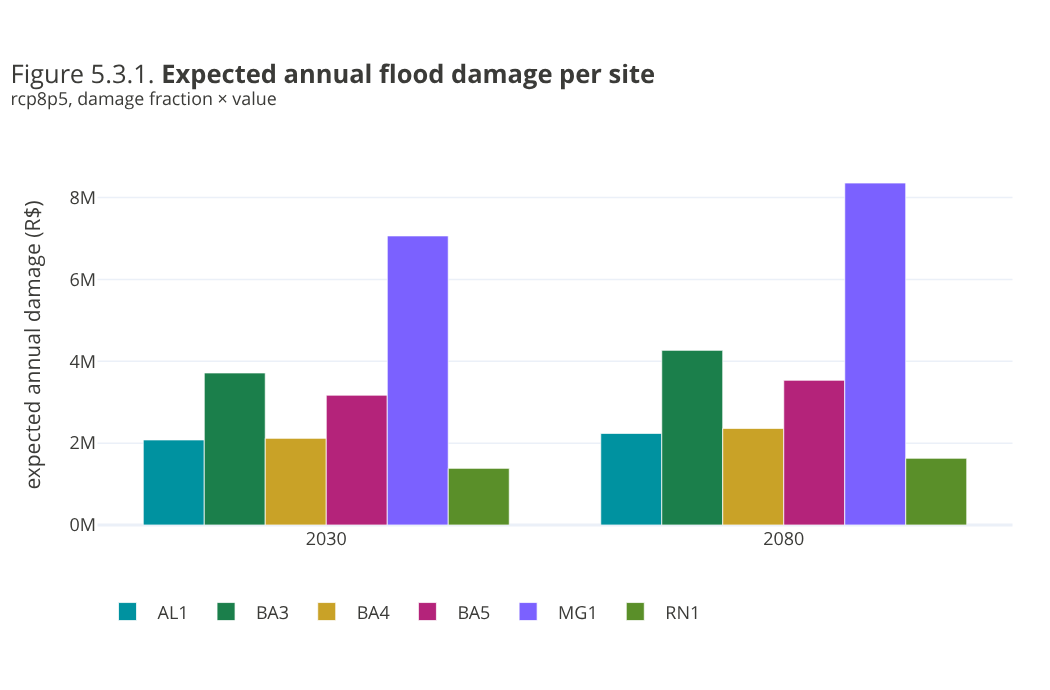

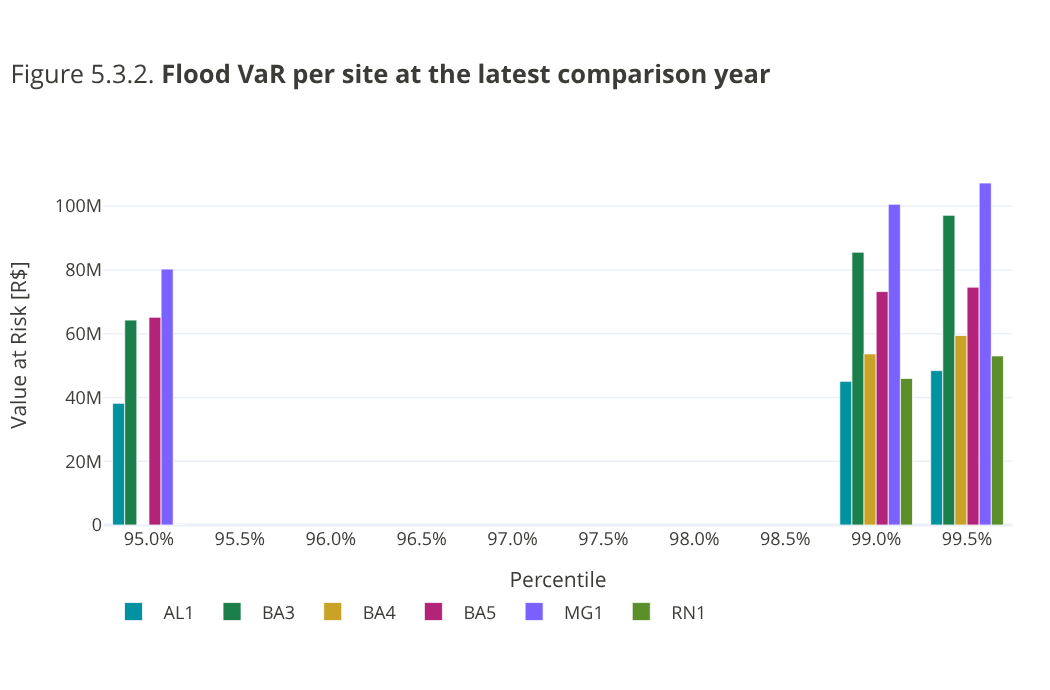

In [41]:
RIVER_DAMAGE_YEAR = max(COMPARISON_YEARS_BY_FAMILY["riverine"])
COASTAL_DAMAGE_YEAR = FOCUS_YEAR

def show_priced_flood(frame, *, family, table_caption, bar_figure, tail_figure):
    subset = br.flood_damage_rows(frame, assets, family=family, scenario=FOCUS_SCENARIO,
                                  years=(BASELINE_YEAR, *COMPARISON_YEARS_BY_FAMILY[family]))
    losses = subset.merge(assets[["id", "value"]], left_on="asset_id", right_on="id")
    losses["expected_loss_brl"] = losses["impact_mean"] * losses["value"]
    display(bf.table(
        losses.set_index(["asset_id", "year"])[["impact_mean", "expected_loss_brl"]]
        .assign(expected_loss_brl=lambda frame: frame["expected_loss_brl"] / 1e6)
        .round({"impact_mean": 4, "expected_loss_brl": 2})
        .rename_axis(["Site", "Year"])
        .rename(columns={"impact_mean": "Damage fraction",
                         "expected_loss_brl": f"Expected annual damage ({br.CURRENCY} M)"}),
        table_caption))
    bars = bf.loss_by_asset_bars(losses, COLOUR, value_col="expected_loss_brl",
                                 currency=br.CURRENCY)
    bf.set_text(bars, title="Expected annual flood damage per site",
                subtitle=f"{FOCUS_SCENARIO}, damage fraction × value",
                y_titles=f"expected annual damage ({br.CURRENCY})")
    bf.finalise(bars, bar_figure)
    tail = {}
    for asset_id, group in losses.groupby("asset_id"):
        row = group.sort_values("year").iloc[-1]
        if row["bin_edges"] and row["probabilities"]:
            tail[asset_id] = tm.var_es(row["bin_edges"], br.normalise_probabilities(row["probabilities"]),
                                       percentiles=TAIL_PERCENTILES, scale=row["value"])
    if tail:
        bf.finalise(
            bf.site_var(tail, COLOUR, currency=br.CURRENCY),
            tail_figure)

show_priced_flood(
    flood_damage, family="riverine",
    table_caption=(f"Table 5.3.1. Riverine damage fraction and expected annual damage per site, "
                   f"{FOCUS_SCENARIO}, {BASELINE_YEAR} and {RIVER_DAMAGE_YEAR}"),
    bar_figure="Figure 5.3.1", tail_figure="Figure 5.3.2")


<a id="s5-4" name="s5-4"></a>

### 5.4 Heat

Heat has two monetary channels: working time lost at producing sites and additional cooling electricity at the office.

The first is valued with the labour cost that was provided as input; the second uses the office's floor area, cooling intensity and tariff.


<a id="s5-4-time" name="s5-4-time"></a>

#### 5.4.1 Working time lost

Heat costs more working time the harder the work, because the body must shed the heat it produces as well as the heat around it. Occupational limits are therefore set on WBGT by metabolic rate (ISO 7243), and the work-ability functions behind global estimates (Kjellstrom et al., 2018; ILO, *Working on a warmer planet*, 2019) assign about 400 W to heavy work such as field labour, construction and manual loading, 300 W to moderate work such as operating machines on a factory floor, and 200 W to light work such as office and service jobs. At the same WBGT, heavy work loses capacity first and fastest, while light work in an air-conditioned room loses almost none.

Table 5.4.1 lists the heat inputs. The platform's productivity models price a site's whole working year as heavy work, and the impact endpoint takes no work intensity. Each producing site therefore splits its revenue across heavy, moderate and light work exposed to heat, the rest being work heat does not reach (section 1.4). Moderate and light work count at the site's work loss for that intensity over its loss for heavy work, at each horizon (section 4.4.3); the resulting weight scales the platform's loss. Table 5.4.2 gives each site's split and weight, and the added share of working time lost relative to the historical baseline. The industrial sites (degree days above 32 °C) and the mills (days above a WBGT threshold) use different indicators and vulnerability models, so their values are not directly comparable. The office in this example is air-conditioned and therefore excluded because its productivity does not decrease and instead its heat impact is through additional cooling demand.


In [42]:
impact_df = pd.concat([impacts(assets[assets["asset_class"] == asset_class], {"ChronicHeat": [indicator]},
                               HEAT_SCENARIOS, HEAT_YEARS, {"ChronicHeat": {indicator: HEAT_PATHS[indicator]}})
                       .assign(asset_class=asset_class, indicator=indicator)
                       for asset_class, indicator in IMPACT_ROUTING.items()], ignore_index=True)
print(f"impacts: {len(impact_df)} heat records across {impact_df['asset_id'].nunique()} assets")


impacts: 50 heat records across 10 assets


In [43]:
INTENSITY_WEIGHTS = br.work_intensity_weights(chronic_heat_df[chronic_heat_df["key"] == "work_loss"], assets)
HEAT_CHANNELS = br.impact_channels(impact_df, assets, cooling=COOLING, output_col="annual_revenue",
                                   labour_share=LABOUR_SHARE, intensity_weights=INTENSITY_WEIGHTS,
                                   change_only=True)
FOCUS_CHANNELS = HEAT_CHANNELS[HEAT_CHANNELS["scenario"] == FOCUS_HEAT_SCENARIO]
SITE_NAMES = assets.set_index("id")["name"]

HEAT_INPUTS = {
    "labour cost share of revenue": (LABOUR_SHARE, "what a lost working hour is valued at (section 1.4)"),
    "work mix of each producing site": ("Table 5.4.2", "revenue share by work intensity; the rest is not exposed (section 1.4)"),
    "work loss against heavy work": (f"OS-Climate, {WORK_LOSS_MODEL}", "weights moderate and light work at each horizon (section 4.4.3)"),
    "office cooling today (kWh per m² a year)": (COOLING["kwh_per_m2_year"], "the office's cooling electricity (section 1.4)"),
    "electricity tariff (R$ per kWh)": (COOLING["price_per_kwh"], "commercial tariff, taxes included (section 1.4)"),
    "heat pathway": (br.label(FOCUS_HEAT_SCENARIO), "the headline heat pathway (section 1.2)"),
    "baseline": (" ".join(map(str, COMPARE["heat"]["baseline"])), "every amount is the change from it"),
}
display(bf.table(pd.DataFrame(HEAT_INPUTS, index=["value", "note"]).T.rename_axis("parameter"),
                 "Table 5.4.1. The heat inputs, with what each stands for"))


,value,note
parameter,,
labour cost share of revenue,0.12,what a lost working hour is valued at (section 1.4)
work mix of each producing site,Table 5.4.2,revenue share by work intensity; the rest is not exposed (section 1.4)
work loss against heavy work,"OS-Climate, NorESM2-MM",weights moderate and light work at each horizon (section 4.4.3)
office cooling today (kWh per m² a year),80,the office's cooling electricity (section 1.4)
electricity tariff (R$ per kWh),0.85,"commercial tariff, taxes included (section 1.4)"
heat pathway,SSP5-8.5,the headline heat pathway (section 1.2)
baseline,historical 2005,every amount is the change from it


In [44]:
labour = FOCUS_CHANNELS[FOCUS_CHANNELS["channel"] == "Productivity loss"]
hours_lost = (labour.assign(pp=labour["money"] / (labour["base"] * LABOUR_SHARE) * 100)
              .pivot_table(index="asset_id", columns="horizon", values="pp")
              .rename(columns=lambda horizon: f"hours lost {horizon.split()[-1]} (%)"))
split = assets.set_index("id")["revenue_by_work_intensity"].dropna()
mix = pd.DataFrame(split.tolist(), index=split.index)[list(br.WORK_INTENSITIES)] * 100
mix["no impact"] = 100 - mix.sum(axis=1)
weights = INTENSITY_WEIGHTS[INTENSITY_WEIGHTS["horizon"] == FOCUS_HEAT].set_index("asset_id")["weight"]
hours_lost = pd.concat([mix.rename(columns=lambda share: f"{share} (%)"),
                        weights.rename(f"weight, {br.label(FOCUS_HEAT)}"), hours_lost], axis=1).loc[hours_lost.index]
hours_lost.insert(0, "asset class", labour.groupby("asset_id")["asset_class"].first())
hours_lost.insert(0, "name", hours_lost.index.map(SITE_NAMES))
display(bf.table(hours_lost.sort_values(f"hours lost {FOCUS_YEAR} (%)", ascending=False).round(2)
                 .rename_axis(index="Site", columns=None),
                 f"Table 5.4.2. Each producing site's revenue by work intensity, the weight it gives the "
                 f"platform's heavy-work loss, and the share of annual working hours lost to heat under "
                 f"{br.label(FOCUS_HEAT_SCENARIO)}, change from the baseline, by site and year"))


,name,asset class,high (%),medium (%),low (%),no impact (%),"weight, SSP5-8.5 2050",hours lost 2030 (%),hours lost 2050 (%)
Site,,,,,,,,,
RN1,Usina Sucroalcooleira do Ceará-Mirim,ManufacturingAsset,20,30,25,25,0.48,3.59,9.43
BA3,Usina de Beneficiamento São Desidério,ManufacturingAsset,5,30,35,30,0.26,2.23,5.19
BA5,Unidade de Beneficiamento de Itagibá,ManufacturingAsset,10,30,30,30,0.28,1.27,5.01
MT5,Centro de Distribuição Cuiabá,IndustrialActivity,5,30,30,35,0.44,0.81,2.1
MT1,Terminal Graneleiro Rondonópolis,IndustrialActivity,5,20,25,50,0.31,0.49,1.35
BA4,Unidade de Armazenagem Formosa do Rio Preto,IndustrialActivity,5,20,25,50,0.22,0.28,0.77
MG1,Terminal Fluvial de Pirapora,IndustrialActivity,5,20,25,50,0.22,0.17,0.54
AL1,Armazém de Piaçabuçu,IndustrialActivity,10,25,25,40,0.31,0.09,0.31
BA6,Terminal Portuário de Nova Viçosa,IndustrialActivity,10,25,20,45,0.25,0.04,0.15


<a id="s5-4-amounts" name="s5-4-amounts"></a>

#### 5.4.2 Heat impacts in reais

Tables 5.4.3–5.4.4 and Figure 5.4.1 show the added annual heat costs by site. In 2050 under SSP5-8.5, producing sites lose R$ 9.26 M a year, 94% of it at the three mills; the office adds R$ 0.38 M to its cooling bill.

,,name,2030 (R$ k a year),2050 (R$ k a year)
Site,Channel,,,
RN1,Productivity loss,Usina Sucroalcooleira do Ceará-Mirim,"1,293.3","3,393.7"
BA3,Productivity loss,Usina de Beneficiamento São Desidério,"1,447.3","3,361.2"
BA5,Productivity loss,Unidade de Beneficiamento de Itagibá,488.3,"1,925.1"
RN2,Energy cost,Centro Administrativo de João Câmara,192.9,383.2
MT1,Productivity loss,Terminal Graneleiro Rondonópolis,83.1,227.1
BA4,Productivity loss,Unidade de Armazenagem Formosa do Rio Preto,50.5,138
MT5,Productivity loss,Centro de Distribuição Cuiabá,46.7,121.2
AL1,Productivity loss,Armazém de Piaçabuçu,13.1,42.5
MG1,Productivity loss,Terminal Fluvial de Pirapora,12.5,38.7


Heat cost SSP5-8.5 adds, all sites (R$ M a year): 2030: 3.63, 2050: 9.64
IndustrialActivity priced on chronic_heat/osc/v2/mean_degree_days_v2_above_32c_ACCESS-CM2_{scenario}_{year}
ManufacturingAsset priced on chronic_heat/osc/v2/days_wbgt_above_ACCESS-CM2_{scenario}_{year}
RealEstateAsset priced on chronic_heat/alpha_klima/v1/cooling_degree_days_index_{scenario}_{year}


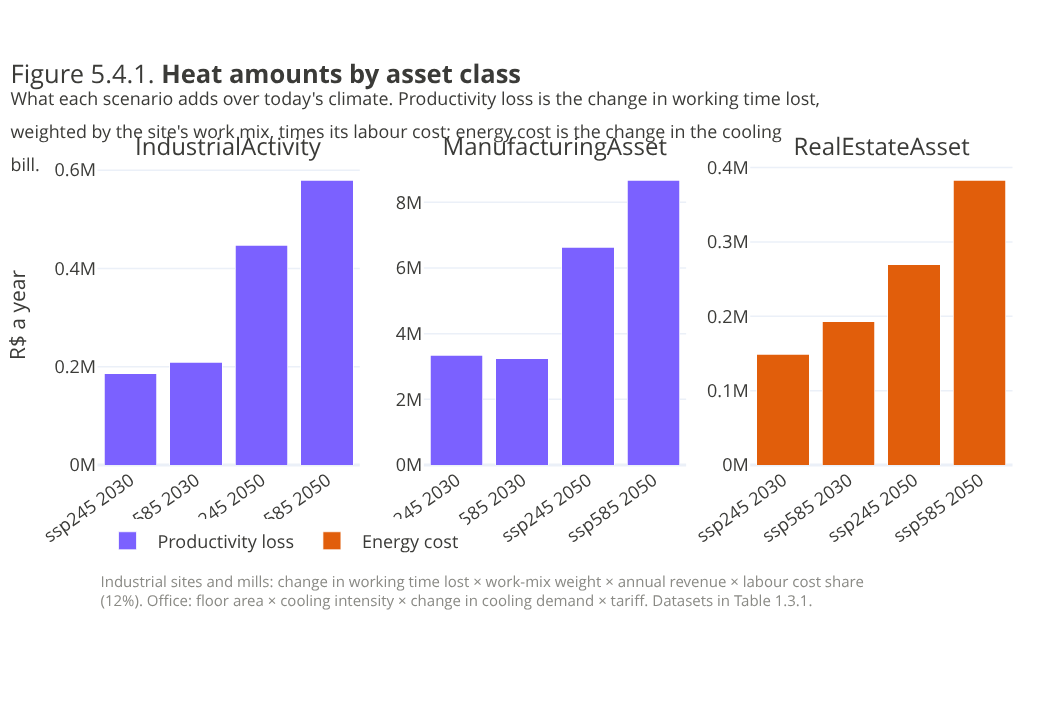

In [45]:
cost = FOCUS_CHANNELS.pivot_table(index=["asset_id", "channel"], columns="horizon", values="money", aggfunc="sum") / 1e3
cost.columns = [f"{horizon.split()[-1]} ({br.CURRENCY} k a year)" for horizon in cost.columns]
cost.insert(0, "name", cost.index.get_level_values("asset_id").map(SITE_NAMES))
display(bf.table(cost.sort_values(f"{FOCUS_YEAR} ({br.CURRENCY} k a year)", ascending=False).round(1)
                 .rename_axis(["Site", "Channel"]),
                 f"Table 5.4.3. Added heat cost under {br.label(FOCUS_HEAT_SCENARIO)}, by site and year "
                 f"({br.CURRENCY} k a year)"))
totals = FOCUS_CHANNELS.groupby("horizon")["money"].sum() / 1e6
print(f"Heat cost {br.label(FOCUS_HEAT_SCENARIO)} adds, all sites ({br.CURRENCY} M a year): "
      + ", ".join(f"{horizon.split()[-1]}: {total:.2f}" for horizon, total in totals.items()))

for asset_class, paths in impact_df.groupby("asset_class")["hazard_path"].unique().items():
    print(f"{asset_class} priced on {', '.join(str(path) for path in paths if path)}")

figure = bf.impact_split_figure(
    HEAT_CHANNELS, currency=br.CURRENCY,
    subtitle="Added productivity loss and cooling cost over the historical baseline.")
bf.set_text(
    figure,
    title="Heat amounts by asset class",
    subtitle=("What each scenario adds over today's climate. Productivity loss is the change in "
              "working time lost, weighted by the site's work mix, times its labour cost; energy cost "
              "is the change in the cooling bill."))
bf.finalise(
    figure, "Figure 5.4.1",
    note=(f"Industrial sites and mills: change in working time lost × work-mix weight × annual "
          f"revenue × labour cost share ({LABOUR_SHARE:.0%}). Office: floor area × cooling intensity × change in "
          "cooling demand × tariff. Datasets in Table 1.3.1."))


In [46]:
bills = br.cooling_energy_cost(impact_df, assets, **COOLING).pivot_table(
    index="asset_id", columns="horizon", values="money")
added = bills[FOCUS_HEAT] - bills["baseline"]
OFFICE = pd.DataFrame({
    "name": bills.index.map(SITE_NAMES),
    "floor area (m²)": assets.set_index("id")["floor_area_m2"].reindex(bills.index),
    **{f"cooling bill, {br.label(horizon)} ({br.CURRENCY} a year)": bills[horizon]
       for horizon in br.horizon_order(bills.columns)
       if horizon == "baseline" or horizon.startswith(FOCUS_HEAT_SCENARIO)},
    f"added cost, {br.label(FOCUS_HEAT)} ({br.CURRENCY} a year)": added})
OFFICE[f"added cost ({br.CURRENCY}/m² a year)"] = added / OFFICE["floor area (m²)"]
OFFICE["increase over the baseline bill (%)"] = added / bills["baseline"] * 100
display(bf.table(OFFICE.rename_axis("Site").round(2),
                 f"Table 5.4.4. The office's cooling bill: baseline, {br.label(FOCUS_HEAT_SCENARIO)} by year, "
                 "and the cost added at the headline horizon"))


,name,floor area (m²),"cooling bill, baseline (R$ a year)","cooling bill, SSP5-8.5 2030 (R$ a year)","cooling bill, SSP5-8.5 2050 (R$ a year)","added cost, SSP5-8.5 2050 (R$ a year)",added cost (R$/m² a year),increase over the baseline bill (%)
Site,,,,,,,,
RN2,Centro Administrativo de João Câmara,"8,000","544,000","736,868","927,192","383,192",47.9,70.44


<a id="s5-5" name="s5-5"></a>

### 5.5 Coastal damage

Table 5.5.1 and Figures 5.5.1–5.5.2 show platform-estimated coastal damage for AL1 and BA6. From 2030 to 2050, expected annual damage rises by R$ 6.13 M at BA6 and R$ 0.57 M at AL1. The estimate combines coastal processes; it does not price sea-level rise and subsidence separately.


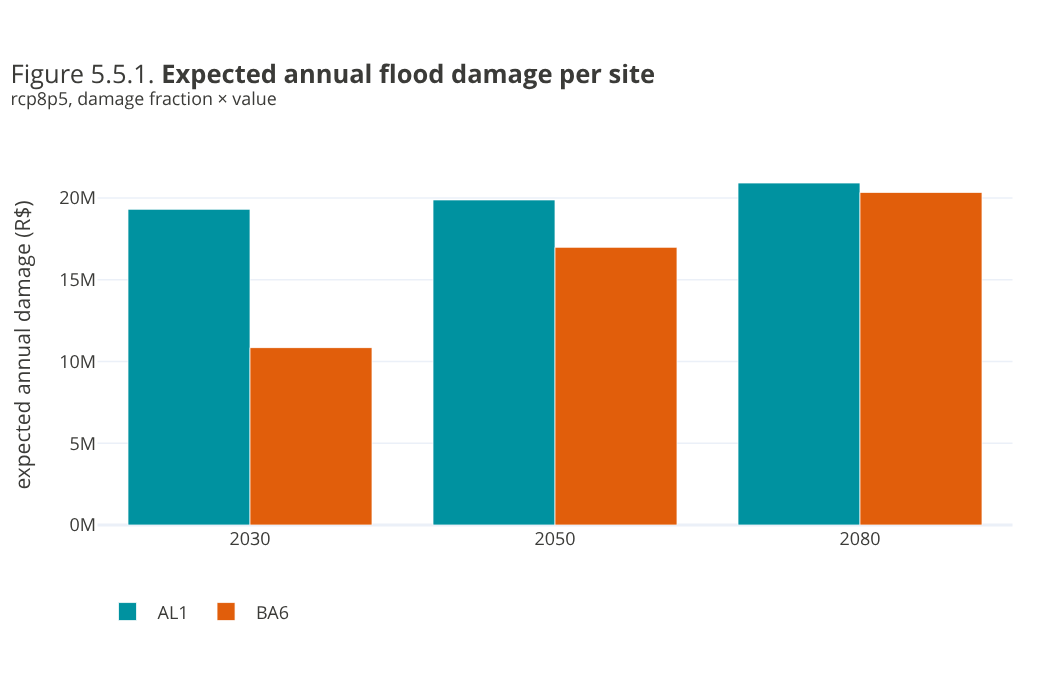

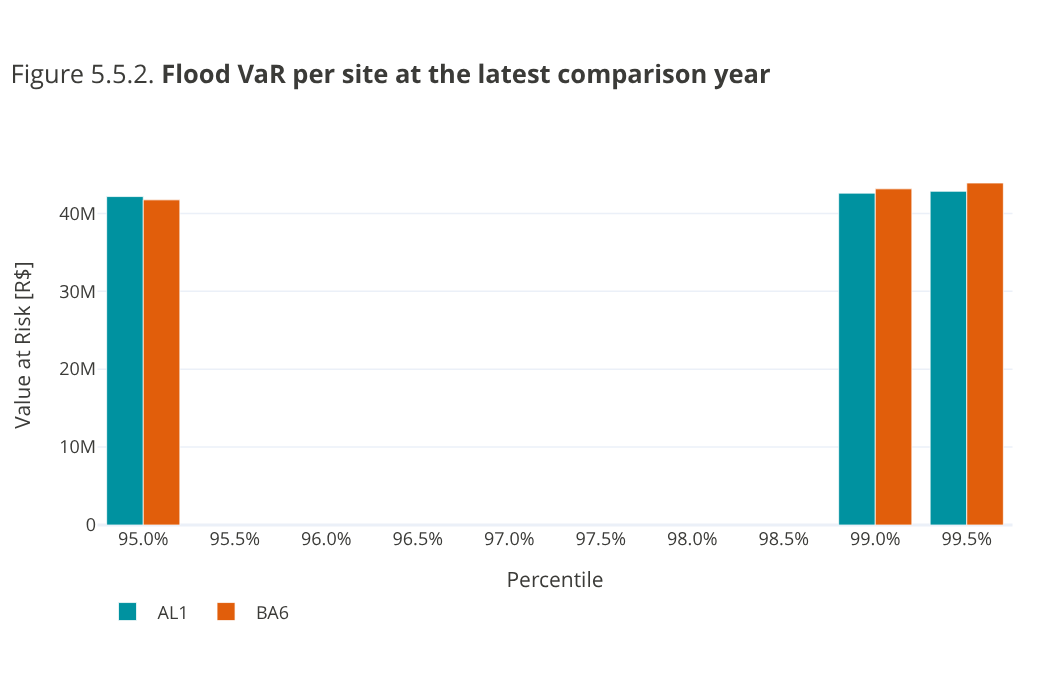

In [47]:
show_priced_flood(
    flood_damage, family="coastal",
    table_caption=(f"Table 5.5.1. Coastal damage fraction and expected annual damage per site, "
                   f"{FOCUS_SCENARIO}, {BASELINE_YEAR}, {COASTAL_DAMAGE_YEAR} and "
                   f"{max(COMPARISON_YEARS_BY_FAMILY['coastal'])}"),
    bar_figure="Figure 5.5.1", tail_figure="Figure 5.5.2")


<a id="s5-6" name="s5-6"></a>

### 5.6 Comparing priced impacts

Table 5.6.1 and Figure 5.6.1 place the annual changes on one scale: heat in 2050 against its historical baseline, coastal damage from 2030 to 2050, and river damage from 2030 to 2080. They cover different sites and years, so the bars compare magnitudes, not a common horizon.

Heat productivity loss is the largest added amount, concentrated in the mills. Coastal expected damage rises at both coastal sites. River damage rises at all six river sites, by R$ 2.86 M a year in total, in line with the higher HadGEM2-ES depths.


In [48]:
loss_table = br.loss_by_hazard(
    HEAT_CHANNELS, flood_damage, assets, heat_horizon=FOCUS_HEAT, flood_scenario=FOCUS_SCENARIO,
    flood_years={"riverine": RIVER_DAMAGE_YEAR, "coastal": COASTAL_DAMAGE_YEAR},
    flood_baseline_year=BASELINE_YEAR)
display(bf.table(
    loss_table,
    f"Table 5.6.1. Loss each hazard adds over its baseline, {br.CURRENCY} M a year and % of the "
    f"sites' annual revenue where applicable: heat {FOCUS_YEAR}, coast {COASTAL_DAMAGE_YEAR}, "
    f"river {RIVER_DAMAGE_YEAR}"))


,,Loss added (R$ M a year),Share of revenue (%),Sites,Status
Hazard,Channel,,,,
Heat,Productivity loss,9.26,0.53,9,priced
Coastal flood,Damage,6.71,3.63,2,priced
River flood,Damage,2.86,0.19,6,priced
Heat,Energy cost,0.38,—,1,priced


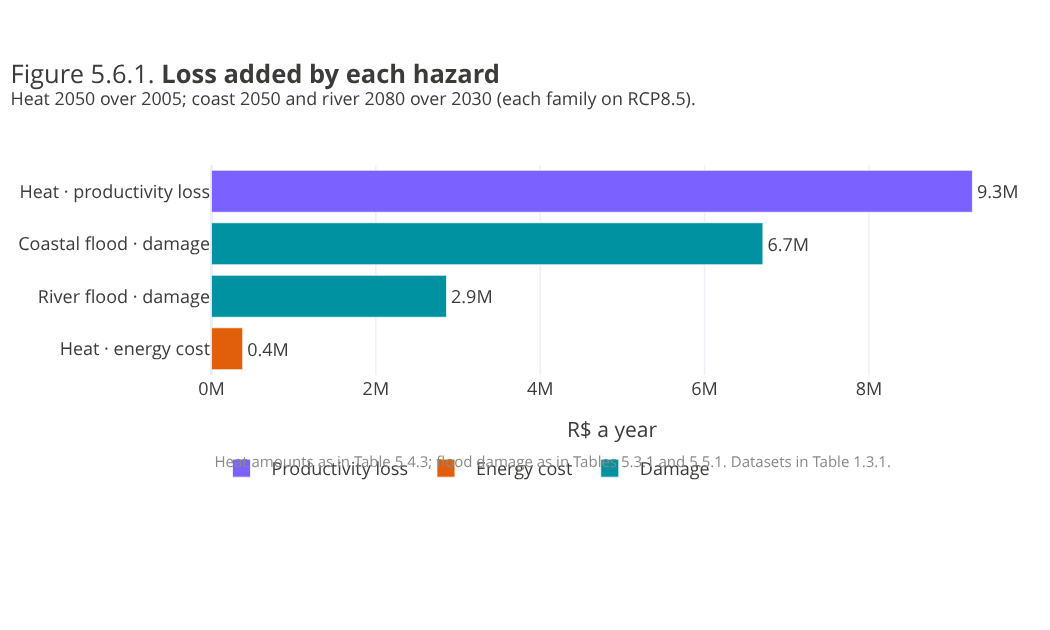

In [49]:
figure = bf.loss_by_hazard_figure(loss_table)
bf.set_text(
    figure,
    title="Loss added by each hazard",
    subtitle=(f"Heat {FOCUS_YEAR} over {COMPARE['heat']['baseline'][1]}; coast "
              f"{COASTAL_DAMAGE_YEAR} and river {RIVER_DAMAGE_YEAR} over {BASELINE_YEAR} (each "
              f"family on {br.label(FOCUS_SCENARIO)})."),
    x_titles=f"{br.CURRENCY} a year")
bf.finalise(
    figure, "Figure 5.6.1",
    note=("Heat amounts as in Table 5.4.3; flood damage as in Tables 5.3.1 and 5.5.1. "
          "Datasets in Table 1.3.1."))


**What the monetary results show.** Heat productivity loss dominates the added annual amounts for this example portfolio; the office cooling bill is a smaller, separate cost. Coastal expected damage rises by R$ 6.71 M a year by 2050, mostly at BA6, and river damage by R$ 2.86 M a year by 2080, most of it at MG1.


<a id="s6" name="s6"></a>

## 6. Portfolio aggregation

Sections 4 and 5 read each site on its own. This section sends the ten sites to the platform's portfolio service, which runs its own risk analysis, groups the sites that one event can hit together and aggregates their losses into a single portfolio distribution. It uses its own hazard set and scenario labels, so its totals are not comparable with the site amounts of Section 5, and they feed neither the CRFR2 report nor the credit results of Section 7.

In [50]:
pipeline = PhysicalAssetPipeline(api_base=API_BASE, api_key=API_KEY, portfolio={
    "portfolio": {"assets": [br.asset_item(row, name_key="name") for _, row in assets.iterrows()]},
    "portfolio_name": PORTFOLIO_NAME})
portfolio_code = pipeline.portfolio_code
RESULTS = f"api/physical-asset-portfolios/{portfolio_code}"
risk = pipeline.run_risk_analysis(requested_results=[f"{RESULTS}/assets/risks"])
clustering = pipeline.run_clustering(requested_results=[f"{RESULTS}/clusters", f"{RESULTS}/clusters/assets"])
asset_risks = pd.DataFrame(risk[f"{RESULTS}/assets/risks"])
clusters, asset_to_cluster = clustering[f"{RESULTS}/clusters"], clustering[f"{RESULTS}/clusters/assets"]

PORTFOLIO_HAZARD = "Combined"
metrics_response = api_get(f"/{RESULTS}/metrics", {"hazard": PORTFOLIO_HAZARD})
print(f"portfolio {portfolio_code} | {len(asset_risks)} risk rows | {len(clusters)} clusters | clustered "
      f"hazards: {', '.join(sorted({entry['hazard'] for entry in clusters}))}")


portfolio 652 | 290 risk rows | 20 clusters | clustered hazards: CoastalInundation, Combined, RiverineInundation, Wind


<a id="s6-1" name="s6-1"></a>

### 6.1 Site risk and clusters

Table 6.1.1 summarises what the risk analysis returns: one row per site, hazard, indicator, scenario and year. The mean impact is on each indicator's own scale, a damage fraction for flood depth and the index value for the heat indicators, so rows of different hazards are not comparable. The risk score is an ordinal class for ranking sites, not a physical unit.

Table 6.1.2 and Figure 6.1.1 show the clusters of the combined hazard footprint. Each hazard is clustered with its own spatial method. Sites in one cluster can be hit by the same event, so their losses are aggregated together; a site alone in its cluster is treated as independent of the rest of the book. This is why the portfolio tail need not equal the sum of the site tails.

In [51]:
display(bf.table(asset_risks.groupby(["hazard", "indicator"]).agg(
    rows=("impact_mean", "size"), mean_impact=("impact_mean", "mean"),
    max_score=("risk_score", "max")).round(4)
    .rename_axis(["Hazard", "Indicator"])
    .rename(columns={"rows": "Rows", "mean_impact": "Mean impact", "max_score": "Maximum risk score"}),
    "Table 6.1.1. Risk rows the portfolio pipeline returns, by hazard and indicator"))


,Value (R$ M),Sites
Cluster,,
Cluster 1,248,"BA5, BA6"
Cluster 2,397,"MT1, MT5"
Cluster 3,279,"RN1, RN2"
Cluster 4,452.5,"BA3, BA4"
Cluster 5,155,MG1
Cluster 6,87,AL1


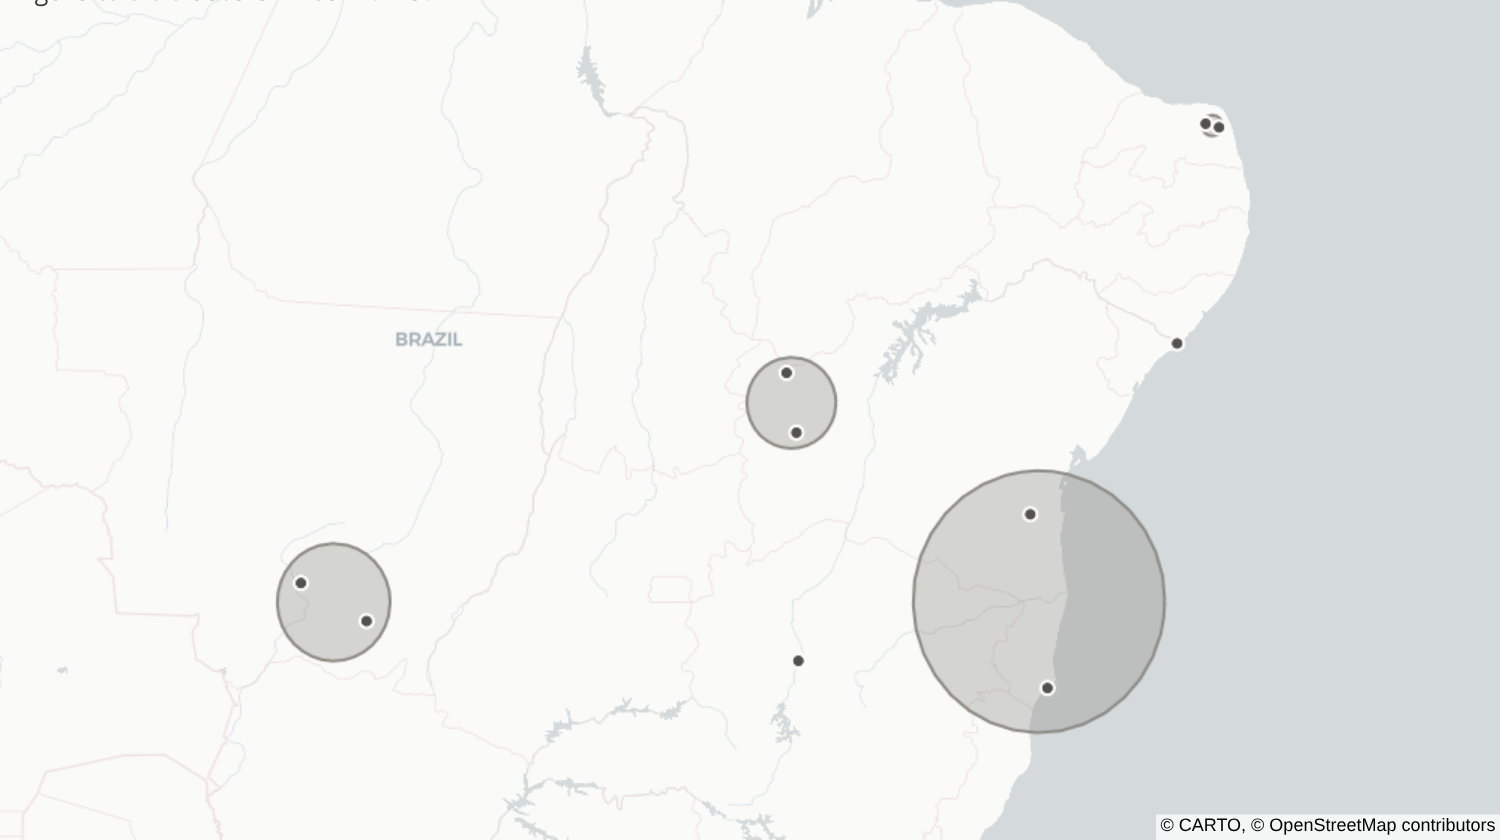

In [52]:
frame = br.cluster_frame(clusters, asset_to_cluster, PORTFOLIO_HAZARD)
display(bf.table(frame.drop(columns="geometry").set_index("cluster_name").rename_axis("Cluster")
                 .assign(assets=lambda f: f["assets"].map(", ".join), value=lambda f: f["value"] / 1e6)
                 .rename(columns={"assets": "Sites", "value": f"Value ({br.CURRENCY} M)"}),
                 f"Table 6.1.2. The clusters of the {PORTFOLIO_HAZARD} hazard footprint"))
figure = gmp.plot_clusters(
    geometries=frame["geometry"], cluster_names=frame["cluster_name"],
    values=frame["value"], asset_lat=assets["latitude"].tolist(),
    asset_lon=assets["longitude"].tolist(), asset_name=assets["name"].tolist(),
    hazard=PORTFOLIO_HAZARD, height=560, fit_to="all", currency="BRL")
bf.set_text(figure, title=f"Clusters — {PORTFOLIO_HAZARD}")
figure.update_layout(margin={"l": 0, "r": 0})
bf.finalise(figure, "Figure 6.1.1")


<a id="s6-2" name="s6-2"></a>

### 6.2 Portfolio loss metrics

Table 6.2.1 and Figures 6.2.1–6.2.2 summarise the portfolio's annual loss distribution under the combined footprint, by scenario and year; the historical row is the baseline.

- Expected loss is the mean annual loss and the standard deviation its spread.
- Value at risk (VaR) is the annual loss at a given percentile of the distribution, here 95% and 99%.
- Expected shortfall (ES) is the average loss beyond those thresholds.

180 metric rows, 180 non-zero


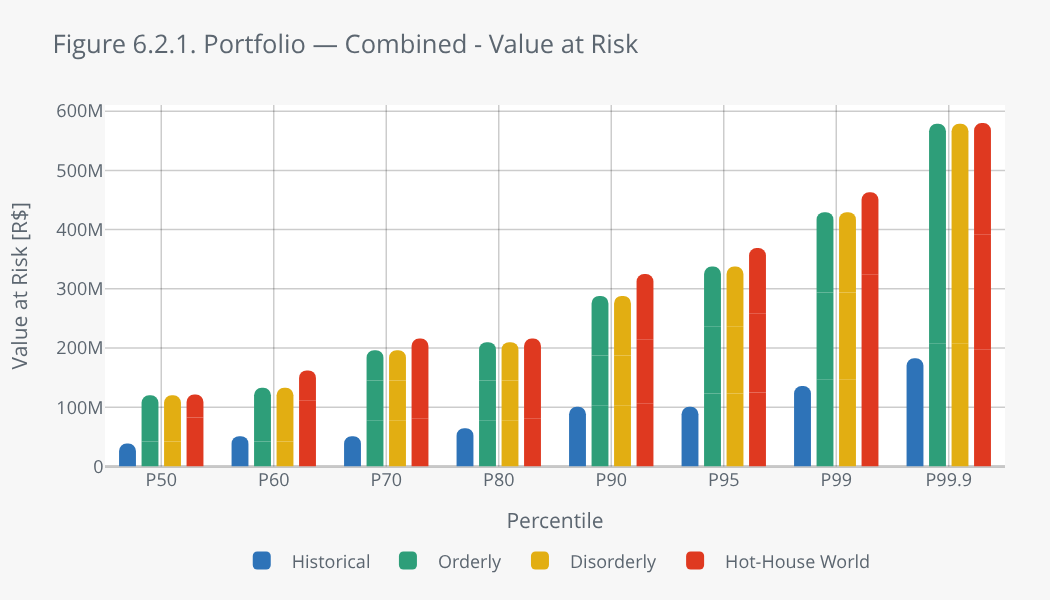

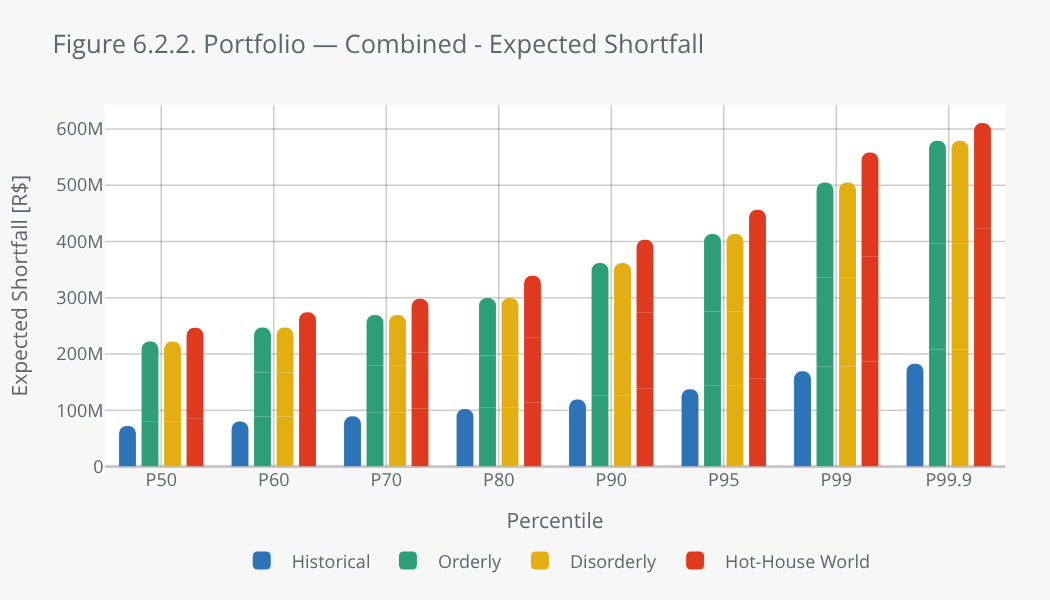

In [53]:
metrics = pd.DataFrame(metrics_response.json())
# The service names monetary metrics in euros; this portfolio sends BRL asset values, so the

populated = metrics[metrics["value"].fillna(0) != 0].assign(
    metric=lambda frame: frame["metric"].str.replace("[€]", "[R$]", regex=False))
print(f"{len(metrics)} metric rows, {len(populated)} non-zero")

keys = [key for key in ("hazard", "metric", "scenario", "year", "term") if key in populated]
shown_metrics = populated.copy()
if "year" in shown_metrics:
    shown_metrics["year"] = shown_metrics["year"].replace(-1, "baseline").astype(str)
display(bf.table(
    shown_metrics.groupby(keys)["value"].max().round(0).to_frame(),
    f"Table 6.2.1. Non-zero portfolio metrics, by {', '.join(keys)}: the largest value "
    "over the percentiles published, in the book's BRL units"))
bf.finalise(fmp.plot_var(metrics_response, name=f"Portfolio — {PORTFOLIO_HAZARD}",
                                 currency=br.CURRENCY), "Figure 6.2.1")
bf.finalise(fmp.plot_es(metrics_response, name=f"Portfolio — {PORTFOLIO_HAZARD}",
                                currency=br.CURRENCY), "Figure 6.2.2")


**What the portfolio results show.** The six clusters group nearby sites: the Mato Grosso sites, the RN sites, BA3 with BA4 and BA5 with BA6, with MG1 and AL1 on their own. Under SSP5-8.5, the combined expected annual loss rises from R$ 44.5 M (historical) to R$ 52.8 M in 2050 and R$ 55.3 M in 2080, and the largest published VaR from R$ 182.8 M to R$ 198.0 M.


<a id="s7" name="s7"></a>

## 7. Impact on loans

This section translates the change in frequency of a fixed 2030 flood depth (Section 4) into borrower PD, expected loss and risk-weighted assets (RWA). Each borrower is assessed on one flood family with a supported frequency curve; Section 5 damage and heat are excluded.

The 2050 total covers two borrowers and R$ 314.5 M of EAD; the 2080 total covers five and R$ 787.0 M, so the percentage changes for the two years refer to different exposures. The [companion](brazil_econometrics_companion.html#credit) describes the credit bridge and loan vintages.


<a id="s7-1" name="s7-1"></a>

### 7.1 From flood frequency to PD

Tables 7.1.1–7.1.2 show how often each site's 2030 1-in-100-year depth occurs in 2050 and 2080; Figures 7.1.1–7.1.2 carry that change through to borrower PD.

PD scales with the frequency ratio at the flood elasticity of BIS Working Paper 1274 (Annex 1):

PD = PD₀ · (1 + 0.134 · (ratio − 1)).

Coastal sites have a supported 2050 frequency; their 2080 result reaches the edge of the published curve and is not priced. River sites have supported 2080 readings.

In 2050 the coastal event occurs 8–9 times as often and PD roughly doubles for C03 and C04.
In 2080 river frequency rises 1.6–2.0 times at borrower level and PD by 8–13%.


Flood event: the 2030 1-in-100-year depth, re-read under rcp8p5 2050. Compared in 2050: coast on nosub 50%.


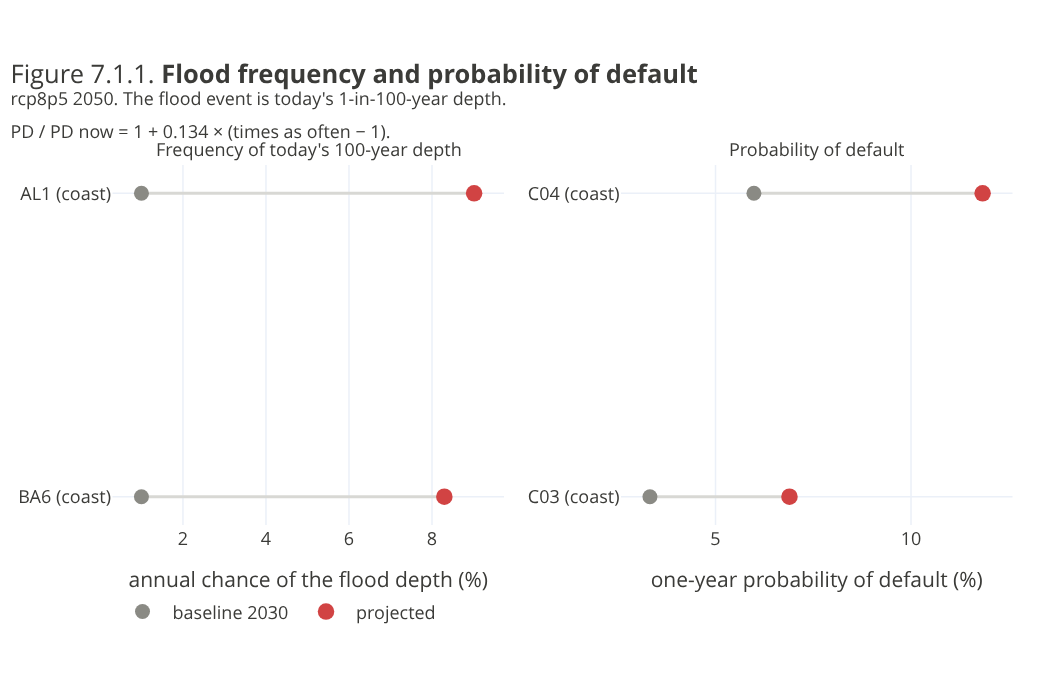

Flood event: the 2030 1-in-100-year depth, re-read under rcp8p5 2080. Compared in 2080: river on HadGEM2-ES, coast on nosub 50%.


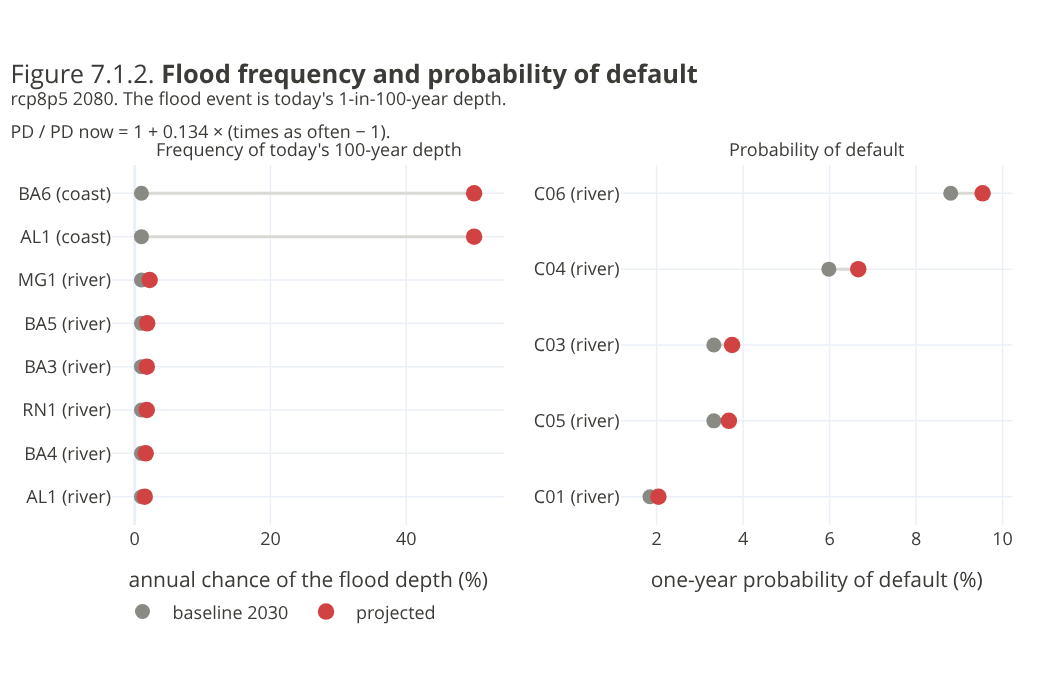

In [54]:
RP0 = FOCUS_RP
LAYER = {"riverine": f"river on {RIVER_MODEL}", "coastal": f"coast on {COASTAL_RESOURCE}"}

def credit_run(scenario, year, coastal_resource=COASTAL_RESOURCE):
    return br.climate_credit(
        book, flood_df, assets, scenario=scenario, year=year, return_period=RP0,
        baseline_year=BASELINE_YEAR, river_model=RIVER_MODEL, coastal_resource=coastal_resource,
        currency=br.CURRENCY)

def compared_families(scenario, year):
    return [family for family in FLOOD_FAMILIES if (scenario, year) in COMPARE[family]["compared"]]

CREDIT = {year: credit_run(FOCUS_SCENARIO, year) for year in COMPARISON_YEARS}
CREDIT_RANGE = {year: {label: credit_run(FOCUS_SCENARIO, year, label) for label in COASTAL_RANGE}
                for year in COMPARISON_YEARS}
SENSITIVITY_PAIRS = sorted({pair for family in FLOOD_FAMILIES
                            for pair in COMPARE[family]["compared"] if pair[0] != FOCUS_SCENARIO})
CREDIT_SENSITIVITY = {pair: credit_run(*pair) for pair in SENSITIVITY_PAIRS}

for index, BIS_YEAR in enumerate(COMPARISON_YEARS, start=1):
    credit = CREDIT[BIS_YEAR]
    table_no = f"7.1.{index}"
    if credit is None:
        print(f"No flood curve inside the published range for {BIS_YEAR}.")
        continue
    families = ", ".join(LAYER[family] for family in compared_families(FOCUS_SCENARIO, BIS_YEAR))
    print(f"Flood event: the {BASELINE_YEAR} 1-in-{RP0:.0f}-year depth, re-read under "
          f"{FOCUS_SCENARIO} {BIS_YEAR}. Compared in {BIS_YEAR}: {families}.")
    sites = credit.assets.set_index(["family", "asset_id"])
    frequency = pd.DataFrame({
        "depth (m)": sites["threshold_m"].round(2),
        f"{BIS_YEAR} (% / year)": (sites["q_scenario"] * 100).round(2),
        "times as often": sites["frequency_ratio"].round(2),
        "published curve": sites["range_end"].map(lambda flag: "end, not priced" if flag else ""),
    })
    if RP0 == 100:

        frequency = frequency.drop(columns=f"{BIS_YEAR} (% / year)")
    display(bf.table(frequency.rename_axis(["Family", "Site"]), f"Table {table_no}. The {BASELINE_YEAR} 1-in-{RP0:.0f}-year depth "
                                f"({100 / RP0:g}% a year in {BASELINE_YEAR}), "
                                f"and how often it occurs under {FOCUS_SCENARIO} {BIS_YEAR}"))
    figure = bf.climate_transmission_figure(credit, COLOUR, baseline_year=BASELINE_YEAR)
    bf.set_text(
        figure,
        title="Flood frequency and probability of default",
        panels=(f"Frequency of today's {RP0:.0f}-year depth", "Probability of default"),
        x_titles=("annual chance of the flood depth (%)", "one-year probability of default (%)"))
    bf.finalise(figure, f"Figure {table_no}")


<a id="s7-2" name="s7-2"></a>

### 7.2 Capital

Tables 7.2.1–7.2.4 and Figures 7.2.1–7.2.2 show expected loss and RWA with LGD unchanged and with a 40% LGD sensitivity. With LGD unchanged, RWA rises by 4.00% for the 2050 eligible total and by 1.93% for the 2080 total, which covers a different set of borrowers. C04's RWA falls by 1.4% in 2050 although its PD rises, a property of the binary credit formula, so portfolio and borrower results should be read separately. The 40% LGD case is a sensitivity, not a collateral forecast.


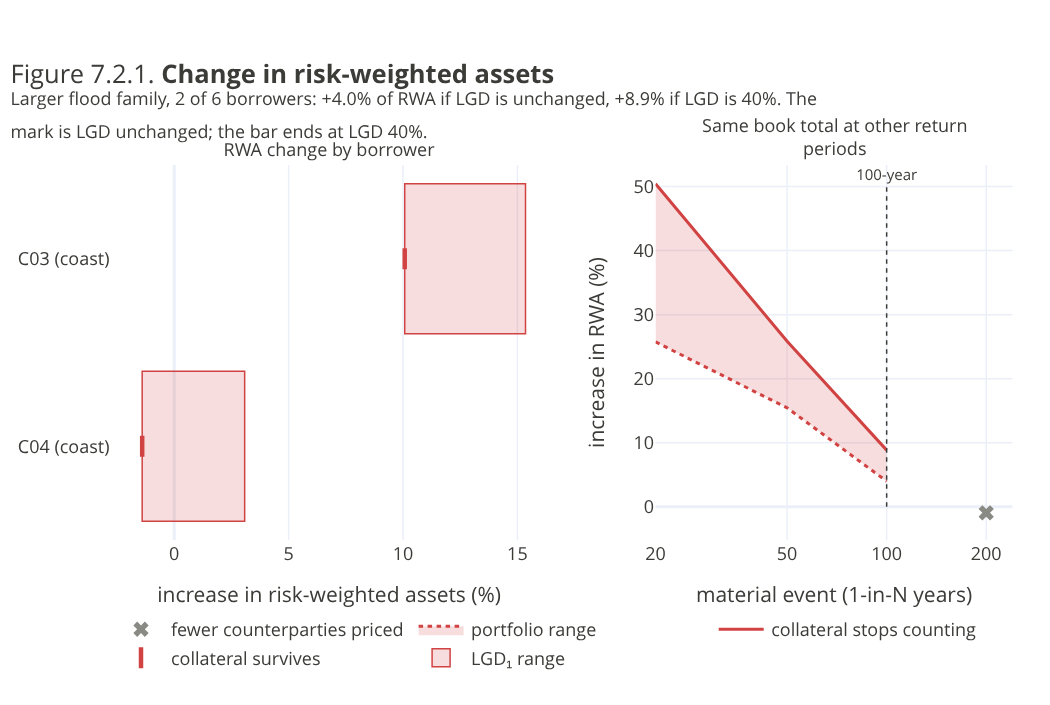

,"larger flood family, 2 of 6 borrowers"
EAD (R$ M),314.5
EL now (R$ M),3.8
"EL, 2050 frequency (R$ M)",7.6
RWA now (R$ M),315.3
"RWA, LGD unchanged (R$ M)",327.9
"RWA, LGD at 40% (R$ M)",343.2
"RWA change, LGD unchanged (%)",4
"RWA change, LGD at 40% (%)",8.85


C01, C05, C06: not in this year's total, no flood family of theirs is compared in 2050. R$ 472.5 M of EAD.
C02: omitted, no flood curve. R$ 259.2 M of EAD.
RWA uses the exact binary-mixture conditional PD. The first-order expression of BIS WP 1274 differs from it by -2.2% to +4.5%.
Coastal sea-level range: at nosub 5%, +3.01% with LGD unchanged, +5.69% with LGD at 40% (2 of 6 borrowers); at nosub 95%, +6.05% with LGD unchanged, +16.94% with LGD at 40% (2 of 6 borrowers).
Sensitivity, rcp4p5 2050 (coast on nosub 50%): +3.22% with LGD unchanged, +6.47% with LGD at 40% (2 of 6 borrowers).
Today's loans still running in 2050: 1 of 12 (C05-TL, R$ 144.6 M of EAD). The rest of the total is loans written later on the same sites and terms (section 7.3).


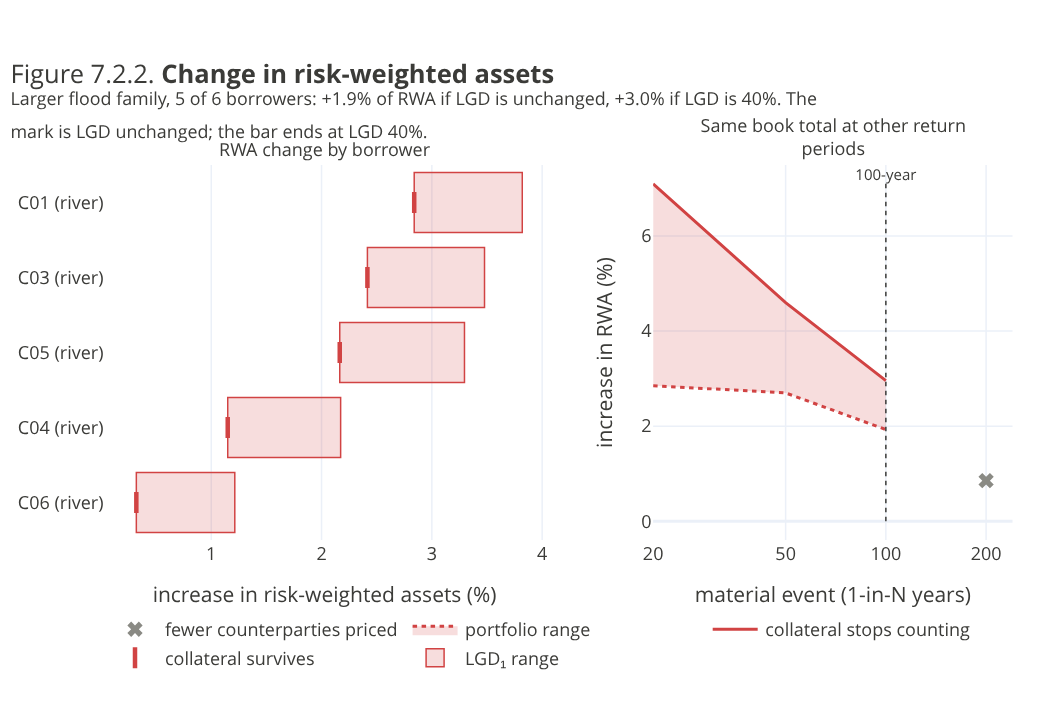

,"larger flood family, 5 of 6 borrowers"
EAD (R$ M),787
EL now (R$ M),8.2
"EL, 2080 frequency (R$ M)",9
RWA now (R$ M),733.2
"RWA, LGD unchanged (R$ M)",747.3
"RWA, LGD at 40% (R$ M)",754.8
"RWA change, LGD unchanged (%)",1.93
"RWA change, LGD at 40% (%)",2.96


C03 coastal: not priced. The 2080 frequency is off the end of the published curve. 1-in-100-year depth, baseline → 2080: AL1 3.03 m → 3.42 m.
C04 coastal: not priced. The 2080 frequency is off the end of the published curve. 1-in-100-year depth, baseline → 2080: BA6 1.02 m → 1.41 m.
C02: omitted, no flood curve. R$ 259.2 M of EAD.
RWA uses the exact binary-mixture conditional PD. The first-order expression of BIS WP 1274 differs from it by -0.9% to +0.3%.
Coastal sea-level range: the coast is off the published curve at every percentile in 2080, so the total above is the river's alone.
Sensitivity, rcp4p5 2080 (coast on nosub 50%): nothing inside the published curve, not priced.
Today's loans still running in 2080: 0 of 12. The rest of the total is loans written later on the same sites and terms (section 7.3).


In [55]:
def rwa_change(result):
    if result is None:
        return "nothing inside the published curve, not priced"
    totals = result.portfolio
    return (f"{totals['RWA uplift, low'] * 100:+.2f}% with LGD unchanged, "
            f"{totals['RWA uplift, high'] * 100:+.2f}% with LGD at 40% "
            f"({len(result.binding)} of {result.total_counterparties} borrowers)")

def credit_view(result):
    low = result.low[result.low["binary_feasible"]]
    high, year, money = result.high.loc[low.index], result.year, f"({result.currency} M)"
    view = pd.DataFrame({
        "PD now (%)": low["pd_baseline"] * 100, f"PD, {year} frequency (%)": low["pd_climate"] * 100,
        "flood chance (% / year)": low["q"] * 100, "times as often": low["frequency_ratio"],
        f"EL now {money}": low["EL_baseline"] / 1e6, f"EL, {year} frequency {money}": low["EL_climate"] / 1e6,
        "RWA change, LGD unchanged (%)": low["RWA_uplift"] * 100,
        "RWA change, LGD at 40% (%)": high["RWA_uplift"] * 100}).round(2)

    if np.isclose(result.return_period, 100.0):
        view = view.drop(columns="flood chance (% / year)")
    return view.sort_values("RWA change, LGD at 40% (%)", ascending=False).rename_axis(["Family", "Borrower"])

def prices_coast(result):
    return result is not None and "coastal" in set(result.binding["family"])

for index, BIS_YEAR in enumerate(COMPARISON_YEARS, start=1):
    credit = CREDIT[BIS_YEAR]
    if credit is None:
        continue
    table_no = f"7.2.{2 * index - 1}"
    summary_no = f"7.2.{2 * index}"
    figure_no = f"7.2.{index}"
    display(bf.table(
        credit_view(credit),
        f"Table {table_no}. PD, expected loss and RWA change by borrower and flood family, "
        f"{FOCUS_SCENARIO} {BIS_YEAR}. {br.CURRENCY} M. LGD unchanged, and LGD at 40%"))

    sensitivity = br.threshold_sensitivity(
        book, flood_df, assets, scenario=FOCUS_SCENARIO, year=BIS_YEAR, return_periods=SENSITIVITY_RPS,
        baseline_year=BASELINE_YEAR, river_model=RIVER_MODEL, coastal_resource=COASTAL_RESOURCE)
    figure = bf.capital_uplift_figure(credit, sensitivity)
    bf.set_text(
        figure,
        title="Change in risk-weighted assets",
        subtitle=(f"Larger flood family, {len(credit.binding)} of {credit.total_counterparties} "
                  f"borrowers: {credit.portfolio['RWA uplift, low']:+.1%} of RWA if LGD is "
                  f"unchanged, {credit.portfolio['RWA uplift, high']:+.1%} if LGD is 40%. The "
                  "mark is LGD unchanged; the bar ends at LGD 40%."),
        panels=("RWA change by borrower", "Same book total at other return periods"),
        x_titles=("increase in risk-weighted assets (%)", "material event (1-in-N years)"),
        y_titles=(None, "increase in RWA (%)"))
    bf.finalise(figure, f"Figure {figure_no}")

    totals, money = credit.portfolio, f"({br.CURRENCY} M)"
    display(bf.table(pd.Series({
        f"EAD {money}": round(totals["EAD"] / 1e6, 1), f"EL now {money}": round(totals["EL baseline"] / 1e6, 1),
        f"EL, {BIS_YEAR} frequency {money}": round(totals["EL climate"] / 1e6, 1),
        f"RWA now {money}": round(totals["RWA baseline"] / 1e6, 1),
        f"RWA, LGD unchanged {money}": round(totals["RWA climate, low"] / 1e6, 1),
        f"RWA, LGD at 40% {money}": round(totals["RWA climate, high"] / 1e6, 1),
        "RWA change, LGD unchanged (%)": round(totals["RWA uplift, low"] * 100, 2),
        "RWA change, LGD at 40% (%)": round(totals["RWA uplift, high"] * 100, 2),
    }).to_frame(f"larger flood family, {len(credit.binding)} of {credit.total_counterparties} borrowers"),
        f"Table {summary_no}. Book total on each borrower's larger flood family, "
        f"{FOCUS_SCENARIO} {BIS_YEAR}, coast at {COASTAL_RESOURCE}"))
    for line in br.credit_notes(credit):
        print(line)

    ends = CREDIT_RANGE[BIS_YEAR]
    if any(prices_coast(result) for result in (credit, *ends.values())):
        print("Coastal sea-level range: "
              + "; ".join(f"at {label}, {rwa_change(ends[label])}" for label in COASTAL_RANGE)
              + ".")
    else:
        print(f"Coastal sea-level range: the coast is off the published curve at every "
              f"percentile in {BIS_YEAR}, so the total above is the river's alone.")
    for scenario, year in SENSITIVITY_PAIRS:
        if year == BIS_YEAR:
            families = ", ".join(LAYER[family] for family in compared_families(scenario, year))
            print(f"Sensitivity, {scenario} {year} ({families}): "
                  f"{rwa_change(CREDIT_SENSITIVITY[(scenario, year)])}.")

    running = br.loans_outstanding(facilities, reference_year=REFERENCE_YEAR,
                                   year=BIS_YEAR)
    named = (f" ({', '.join(running['facility_id'])}, {br.CURRENCY} "
             f"{running['ead'].sum() / 1e6:,.1f} M of EAD)" if len(running) else "")
    print(f"Today's loans still running in {BIS_YEAR}: {len(running)} of {len(facilities)}"
          f"{named}. The rest of the total is loans written later on the same sites and "
          "terms (section 7.3).")


<a id="s7-life" name="s7-life"></a>

### 7.3 Loans written later

Tables 7.3.1–7.3.3 compare today's loans with otherwise identical loans written in 2040, 2050 and 2080. Later vintages spend more of their lives under the changed flood frequency, so the lifetime expected-loss change of the eligible book rises from 5.3% for 2028 loans to 52.2% for 2080 loans. The change is relative to each vintage's own baseline expected loss; about 75% of EAD has a usable flood curve. Flood frequency and heat costs are held at their last supported year rather than extrapolated; for C03 and C04 this holds the coastal frequency at its 2050 value, so their later vintages are understated.


In [56]:
VINTAGES = [REFERENCE_YEAR + 1, *(year for year in LOAN_VINTAGES if year > REFERENCE_YEAR + 1)]
WRITTEN_LATER = br.loans_written_later(facilities, CREDIT, vintages=VINTAGES,
                                       baseline_year=BASELINE_YEAR)
display(bf.table(WRITTEN_LATER,
                 f"Table 7.3.1. Each loan written in {VINTAGES[0]} (today's) and again later: how "
                 "many times as often the material flood arrives over its life, and the change in "
                 f"its expected loss, {FOCUS_SCENARIO}"))

BOOK_LATER = br.book_written_later(WRITTEN_LATER, facilities, book, vintages=VINTAGES)
display(bf.table(BOOK_LATER.infer_objects().round(2),
                 "Table 7.3.2. The book written in each year: the change in expected loss the flood "
                 "adds over the loans' lives"))
EL_CHANGE = "EL change over the loans' lives (%)"
for vintage, row in BOOK_LATER.iterrows():
    today = br.loans_outstanding(facilities, reference_year=REFERENCE_YEAR, year=vintage)
    print(f"Written in {vintage}: the flood adds {row[EL_CHANGE]:+.1f}% to the "
          f"expected loss of the loans with a flood curve ({row['EAD with a flood curve (%)']:.0f}% of EAD), "
          f"largest on {row['largest, loan']} ({row['largest (%)']:+.1f}%). Of today's loans, {len(today)} of "
          f"{len(facilities)} are still running that year.")

HEAT_LATER = br.heat_written_later(facilities, book, HEAT_CHANNELS, assets, vintages=VINTAGES,
                                   heat_scenario=FOCUS_HEAT_SCENARIO)
display(bf.table(HEAT_LATER,
                 f"Table 7.3.3. Annual heat cost added at each borrower's sites under {FOCUS_HEAT_SCENARIO}, "
                 "averaged over the life of its term loan written in each year; years past the last "
                 "heat horizon hold its value"))


,EL change over the loans' lives (%),"largest, loan",largest (%),EAD with a flood curve (%)
Written in,,,,
2028,5.34,C03-TL,24.78,75.23
2040,32.09,C03-TL,83.49,75.23
2050,49.47,C03-WC,107.4,75.23
2080,52.21,C03-WC,107.4,75.23


Written in 2028: the flood adds +5.3% to the expected loss of the loans with a flood curve (75% of EAD), largest on C03-TL (+24.8%). Of today's loans, 12 of 12 are still running that year.
Written in 2040: the flood adds +32.1% to the expected loss of the loans with a flood curve (75% of EAD), largest on C03-TL (+83.5%). Of today's loans, 3 of 12 are still running that year.
Written in 2050: the flood adds +49.5% to the expected loss of the loans with a flood curve (75% of EAD), largest on C03-WC (+107.4%). Of today's loans, 1 of 12 are still running that year.
Written in 2080: the flood adds +52.2% to the expected loss of the loans with a flood curve (75% of EAD), largest on C03-WC (+107.4%). Of today's loans, 0 of 12 are still running that year.


<a id="s7-next" name="s7-next"></a>

### 7.4 Limits of the credit results

The credit results cover one flood family per borrower and only sites with a supported frequency curve. They exclude heat, early default and discounting. The PD and LGD sensitivities are illustrative; they are not a validated bank model or a regulatory disclosure.


<a id="s8" name="s8"></a>

## 8. Results and exported tables

**Main results.**
- Filing at the financed sites moves R$ 290.4 M, 30% of gross exposure, to another macro-region and changes the class of 15 CRFR2 cells.
- Intense-rain threat is lower at every site than at its borrower's headquarters; drought threat is higher at six of the ten sites.
- Site readings diverge from the municipal indices: several sites in high-scoring municipalities have no modelled flood depth, while AL1 has substantial coastal depth.
- Heat productivity loss is the largest priced amount: R$ 9.26 M a year by 2050 under SSP5-8.5.
- River flood damage rises by R$ 2.86 M a year by 2080 across the six river sites.
- Flood frequency raises RWA by 4.00% for the two coastal borrowers in 2050 and by 1.93% for the five river borrowers in 2080.

Table 8.1 gathers the headline results and their source tables. Read each result with its year, eligible sites or borrowers and baseline; a lower percentage in a later year need not describe the same exposure. The [companion](brazil_econometrics_companion.html#results) follows the figure sequence.


In [57]:
def _heat(channel):
    rows = FOCUS_CHANNELS[(FOCUS_CHANNELS["horizon"] == FOCUS_HEAT) & (FOCUS_CHANNELS["channel"] == channel)]
    amount = rows["money"].sum()
    if channel == "Energy cost":
        return (f"{br.CURRENCY} {amount / 1e6:,.2f} M a year ({br.CURRENCY} "
                f"{amount / OFFICE['floor area (m²)'].sum():,.1f}/m²; "
                f"{amount / bills['baseline'].sum() * 100:.0f}% above the baseline cooling bill)")
    revenue = assets.set_index("id")["annual_revenue"].reindex(rows["asset_id"].unique()).sum()
    return f"{br.CURRENCY} {amount / 1e6:,.2f} M a year ({amount / revenue * 100:.2f}% of the sites' revenue)"

def _flood_damage(hazard):
    row = loss_table.loc[(hazard, br.DAMAGE_CHANNEL)]
    if row["Status"] != "priced":
        return br.NOT_PRICED
    return f"{br.CURRENCY} {row[br.LOSS_COLUMN]:+,.2f} M a year ({int(row['Sites'])} sites)"

_base = flood_steps[flood_steps["year"] == BASELINE_YEAR]
HEADLINE = [
    ("Book", f"{len(clients)} borrowers, {len(assets)} sites, {br.CURRENCY} "
             f"{clients['drawn_brl'].sum() / 1e6:,.0f} M drawn, {br.CURRENCY} "
             f"{assets['value'].sum() / 1e6:,.0f} M of collateral", "Tables 2.1.1, 2.3.1"),
    ("Exposure filed in another macro-region at Nível 1",
     f"{br.CURRENCY} {MOVED_AMOUNT / 1e6:,.1f} M, {MOVED_SHARE:.0%} of the book", "Section 3.3"),
    ("CRFR2 cells whose class changes, Nível 3 to Nível 1", f"{len(shown)}", "Tables 3.3.1.a–b"),
    (f"Material flood on the sites' ground, {BASELINE_YEAR}",
     f"{_base['site_depth'].min():.2f} m to {_base['site_depth'].max():.2f} m", "Table 4.3.1"),
    (f"Heat productivity loss added, {FOCUS_HEAT}", _heat("Productivity loss"), "Table 5.4.3"),
    (f"Heat energy cost added, {FOCUS_HEAT}", _heat("Energy cost"), "Tables 5.4.3, 5.4.4"),
    (f"Coastal flood damage added, {COASTAL_DAMAGE_YEAR}", _flood_damage("Coastal flood"), "Table 5.6.1"),
    (f"River flood damage added, {RIVER_DAMAGE_YEAR}", _flood_damage("River flood"), "Table 5.6.1"),
]
for year in COMPARISON_YEARS:
    running = br.loans_outstanding(facilities, reference_year=REFERENCE_YEAR, year=year)
    HEADLINE.append((f"Book RWA change, {FOCUS_SCENARIO} {year}",
                     f"{rwa_change(CREDIT[year])}; {len(running)} of {len(facilities)} of "
                     "today's loans still running", f"Table 7.2.{2 * (COMPARISON_YEARS.index(year) + 1)}"))
_output = HEAT_LATER.xs("Productivity loss", level="Channel")
for vintage, row in BOOK_LATER.iterrows():
    HEADLINE.append((
        f"Loans written in {vintage}" + (" (today's)" if vintage == VINTAGES[0] else ""),
        f"the flood adds {row[EL_CHANGE]:+.1f}% to expected loss over their lives; "
        f"heat costs {br.CURRENCY} {_output[(f'written in {vintage}', f'{br.CURRENCY} M a year')].sum():,.1f} M "
        "a year in lost working time", "Tables 7.3.2, 7.3.3"))

bf.table(pd.DataFrame(HEADLINE, columns=["Result", "Value", "From"]).set_index("Result"),
         "Table 8.1. Headline results and their source tables")


,Value,From
Result,,
Book,"6 borrowers, 10 sites, R$ 971 M drawn, R$ 1,618 M of collateral","Tables 2.1.1, 2.3.1"
Exposure filed in another macro-region at Nível 1,"R$ 290.4 M, 30% of the book",Section 3.3
"CRFR2 cells whose class changes, Nível 3 to Nível 1",15,Tables 3.3.1.a–b
"Material flood on the sites' ground, 2030",0.52 m to 3.14 m,Table 4.3.1
"Heat productivity loss added, ssp585 2050",R$ 9.26 M a year (0.53% of the sites' revenue),Table 5.4.3
"Heat energy cost added, ssp585 2050",R$ 0.38 M a year (R$ 47.9/m²; 70% above the baseline cooling bill),"Tables 5.4.3, 5.4.4"
"Coastal flood damage added, 2050",R$ +6.71 M a year (2 sites),Table 5.6.1
"River flood damage added, 2080",R$ +2.86 M a year (6 sites),Table 5.6.1
"Book RWA change, rcp8p5 2050","+4.00% with LGD unchanged, +8.85% with LGD at 40% (2 of 6 borrowers); 1 of 12 of today's loans still running",Table 7.2.2


<a id="s8-2" name="s8-2"></a>

### 8.2 Exported tables

The cell below writes the results as CSV files to the notebook's `outputs` folder and previews the first rows of the site table. An empty value means a channel was not covered or compared, not zero.


In [58]:
# utf-8-sig so a spreadsheet reads the Portuguese names.
CSV = {"index": False, "encoding": "utf-8-sig"}

A = assets.set_index("id")[["client_id", "name", "municipality", "uf", "asset_class", "latitude", "longitude",
                            "value", "annual_revenue"]].rename(columns={
    "value": f"value ({br.CURRENCY})", "annual_revenue": f"annual revenue ({br.CURRENCY}/yr)"})
sites = exposures.set_index("asset_id")
for name, hazard in (("Seca", seca_hazard), ("Chuva Intensa", chuva_hazard)):
    index_2030 = hazard[hazard["horizon"] == "2030"].set_index("geocod_ibge")["value"]
    A[f"CRFR2 {name} index 2030, headquarters (0-1)"] = sites["hq_geocod_ibge"].map(index_2030)
    A[f"CRFR2 {name} index 2030, site (0-1)"] = sites["geocod_ibge"].map(index_2030)
depth = flood_steps.pivot_table(index="asset_id", columns=["family", "year"], values="site_depth")
A = A.join(depth.set_axis([f"1-in-{FOCUS_RP:.0f} flood on the ground, {f} {y} (m)" for f, y in depth.columns], axis=1))
ratio = pd.concat({year: result.assets.set_index(["asset_id", "family"])["frequency_ratio"]
                   for year, result in CREDIT.items() if result is not None}, names=["year"]).unstack(["family", "year"])
A = A.join(ratio.set_axis([f"material flood, times as often, {f} {FOCUS_SCENARIO} {y}" for f, y in ratio.columns], axis=1))
damage = pd.concat([br.flood_damage_rows(flood_damage, assets, family=family, scenario=FOCUS_SCENARIO,
                                         years=(BASELINE_YEAR, *COMPARISON_YEARS_BY_FAMILY[family])).assign(family=family)
                    for family in FLOOD_FAMILIES])
damage = damage.assign(money=damage["impact_mean"] * damage["asset_id"].map(assets.set_index("id")["value"]),
                       year=damage["year"].astype(int)).pivot_table(index="asset_id", columns=["family", "year"],
                                                                    values="money")
A = A.join(damage.set_axis([f"expected damage, {f} {y} ({br.CURRENCY}/yr)" for f, y in damage.columns], axis=1))
heat = FOCUS_CHANNELS.pivot_table(index="asset_id", columns=["channel", "horizon"], values="money", aggfunc="sum")
A = A.join(heat.set_axis([f"heat {c.lower()} added, {br.label(h)} ({br.CURRENCY}/yr)" for c, h in heat.columns], axis=1))
A.rename_axis("site").reset_index().to_csv(OUTPUTS / "t_asset_results.csv", **CSV)

rows = []

def add(section, metric, value, unit, *, scenario="", year="", scope="book", note=""):
    rows.append({"section": section, "metric": metric, "scenario": scenario, "year": year, "scope": scope,
                 "value": value, "unit": unit, "note": note})

for metric, value in (("drawn balance", clients["drawn_brl"].sum()), ("EAD", book["ead"].sum()),
                      ("collateral", assets["value"].sum()), ("expected loss, baseline", book["EL_baseline"].sum())):
    add("book", metric, value, br.CURRENCY)
add("CRFR2", "gross exposure filed in another macro-region at Nível 1", MOVED_AMOUNT, br.CURRENCY,
    note=", ".join(MOVED_BORROWERS))
add("CRFR2", "disclosed cells whose class changes, Nível 3 to Nível 1", len(shown), "cells")
for (scenario, horizon, channel), value in (HEAT_CHANNELS[HEAT_CHANNELS["horizon"] != "baseline"]
                                            .groupby(["scenario", "horizon", "channel"])["money"].sum().items()):
    add("heat", f"{channel.lower()} added over the baseline", value, f"{br.CURRENCY}/yr", scenario=scenario,
        year=horizon.split()[-1], scope="all sites")
for (hazard, channel), row in loss_table.iterrows():
    add("loss by hazard", f"{hazard}, {channel.lower()}", row[br.LOSS_COLUMN] * 1e6, f"{br.CURRENCY}/yr",
        scope=f"{row['Sites']} sites", note=row["Status"])
for year, result in CREDIT.items():
    if result is None:
        continue
    for key, lgd in (("low", "LGD unchanged"), ("high", "LGD at 40%")):
        add("credit", f"RWA change, {lgd}", result.portfolio[f"RWA uplift, {key}"] * 100, "%",
            scenario=FOCUS_SCENARIO, year=year, note=f"{len(result.binding)} of {result.total_counterparties} borrowers")
    add("credit", "expected loss, climate-adjusted", result.portfolio["EL climate"], br.CURRENCY,
        scenario=FOCUS_SCENARIO, year=year)
    for client_id, row in result.binding.iterrows():
        add("credit", "PD, climate-adjusted", row["pd_climate"] * 100, "%", scenario=FOCUS_SCENARIO, year=year,
            scope=client_id, note=f"{row['family']} flood")
        add("credit", "RWA change, LGD unchanged", row["RWA_uplift"] * 100, "%", scenario=FOCUS_SCENARIO,
            year=year, scope=client_id, note=f"{row['family']} flood")
for (scenario, year), result in CREDIT_SENSITIVITY.items():
    if result is not None:
        add("credit sensitivity", "RWA change, LGD unchanged", result.portfolio["RWA uplift, low"] * 100, "%",
            scenario=scenario, year=year)
for vintage, row in BOOK_LATER.iterrows():
    add("loans written later", "expected loss change over the loans' lives",
        row["EL change over the loans' lives (%)"], "%", scenario=FOCUS_SCENARIO, year=vintage,
        note=f"{row['EAD with a flood curve (%)']:.0f}% of EAD with a flood curve")
for _, row in populated.iterrows():
    add("portfolio pipeline", f"{row['metric']} {row.get('percentile', '')}".strip(), row["value"], br.CURRENCY,
        scenario=row.get("scenario", ""), year=row.get("year", ""), scope=PORTFOLIO_HAZARD, note=row.get("term", ""))
SUMMARY = pd.DataFrame(rows)
SUMMARY.to_csv(OUTPUTS / "t_portfolio_summary.csv", **CSV)

for name, grid in {"t_crfr2_seca_nivel3": seca_hq, "t_crfr2_chuva_intensa_nivel3": chuva_hq,
                   "t_crfr2_seca_nivel1": seca_asset, "t_crfr2_chuva_intensa_nivel1": chuva_asset}.items():
    grid.set_axis([" · ".join(part for part in column if part) for column in grid.columns], axis=1) \
        .rename_axis("row").reset_index().to_csv(OUTPUTS / f"{name}.csv", **CSV)
shown.to_csv(OUTPUTS / "t_crfr2_class_changes.csv", **CSV)
print(f"Written to {OUTPUTS}: t_asset_results.csv ({A.shape[0]} sites, {A.shape[1] + 1} columns), "
      f"t_portfolio_summary.csv ({len(SUMMARY)} rows), the four CRFR2 grids and t_crfr2_class_changes.csv")
display(A.iloc[:3, :12])


Written to outputs: t_asset_results.csv (10 sites, 31 columns), t_portfolio_summary.csv (223 rows), the four CRFR2 grids and t_crfr2_class_changes.csv


,client_id,name,municipality,uf,asset_class,latitude,longitude,value (R$),annual revenue (R$/yr),"CRFR2 Seca index 2030, headquarters (0-1)","CRFR2 Seca index 2030, site (0-1)","CRFR2 Chuva Intensa index 2030, headquarters (0-1)"
id,,,,,,,,,,,,
AL1,C03,Armazém de Piaçabuçu,Piaçabuçu,AL,IndustrialActivity,-10.4016,-36.4547,87000000,115000000,0.58,0.92,0.83
BA6,C04,Terminal Portuário de Nova Viçosa,Nova Viçosa,BA,IndustrialActivity,-17.8700,-39.3550,136500000,70000000,0.96,0.91,0.83
MG1,C03,Terminal Fluvial de Pirapora,Pirapora,MG,IndustrialActivity,-17.2914,-44.9266,155000000,60000000,0.58,0.58,0.83
